In [3]:
!python -m spacy download es_core_news_sm

import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 75.4 MB/s eta 0:00:0000:010:01
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
# load the model(Spanish spaCy model)
nlp = spacy.load("es_core_news_sm")

EDA (no missing value --> analysis)

In [5]:
# load dataset
path_df = '/kaggle/input/private-dataset/WinoMT_with_translations.csv'
df = pd.read_csv(path_df)

# show the dataset basic info
print(df.shape)
print(df.columns)
print(df.isnull().sum())
print(df.duplicated().sum())

print(df["gender"].value_counts())
print(df["label"].value_counts())
print(df["target"].nunique())
print(df["idx"].nunique())

(3168, 8)
Index(['gender', 'idx', 'text', 'target', 'label', 'es_googletranslate',
       'es_systran', 'es_deepl'],
      dtype='object')
gender                0
idx                   0
text                  0
target                0
label                 0
es_googletranslate    0
es_systran            0
es_deepl              0
dtype: int64
5
gender
male      1586
female    1582
Name: count, dtype: int64
label
anti    1584
pro     1584
Name: count, dtype: int64
40
12


In [6]:
print(df["target"].value_counts().head(20))
print(pd.crosstab(df["gender"], df["label"]))
print(pd.crosstab(df["target"], df["gender"]).head(20))

target
accountant      84
janitor         84
tailor          81
attendant       81
developer       80
designer        80
mechanic        80
clerk           80
carpenter       80
counselor       80
supervisor      80
mover           80
chief           80
salesperson     80
librarian       80
hairdresser     80
receptionist    80
driver          80
nurse           80
cashier         80
Name: count, dtype: int64
label   anti  pro
gender           
female   790  792
male     794  792
gender               female  male
target                           
CEO                      36    36
accountant               42    42
analyst                  38    38
assistant                38    38
attendant                40    41
auditor                  38    38
baker                    40    40
carpenter                40    40
cashier                  40    40
chief                    40    40
cleaner                  40    40
clerk                    40    40
construction worker      40    40
cook 

In [7]:
# sentence char
for col in ["text", "es_googletranslate", "es_systran", "es_deepl"]:
    df[col + "_chars"] = df[col].str.len()
    df[col + "_words"] = df[col].str.split().str.len()

print(df[[c for c in df.columns if c.endswith("_chars") or c.endswith("_words")]].describe())

        text_chars   text_words  es_googletranslate_chars  \
count  3168.000000  3168.000000               3168.000000   
mean     73.428346    12.971907                 77.155619   
std      12.577386     2.223855                 15.666603   
min      43.000000     8.000000                 39.000000   
25%      65.000000    11.000000                 66.000000   
50%      72.000000    13.000000                 76.000000   
75%      81.000000    14.000000                 86.000000   
max     138.000000    21.000000                160.000000   

       es_googletranslate_words  es_systran_chars  es_systran_words  \
count               3168.000000       3168.000000       3168.000000   
mean                  13.448232         76.794192         13.508838   
std                    2.586276         15.648772          2.580180   
min                    8.000000         37.000000          8.000000   
25%                   12.000000         66.000000         12.000000   
50%                   13

In [8]:
# translate agreement
print((df["es_googletranslate"] == df["es_systran"]).mean())
print((df["es_googletranslate"] == df["es_deepl"]).mean())
print((df["es_systran"] == df["es_deepl"]).mean())

all_same = (
    (df["es_googletranslate"] == df["es_systran"]) &
    (df["es_googletranslate"] == df["es_deepl"])
).mean()

print("all same:", all_same)

0.2345328282828283
0.13162878787878787
0.09785353535353536
all same: 0.059343434343434344


In [9]:
sample_cols = [
    "gender", "idx", "text", "target", "label",
    "es_googletranslate", "es_systran", "es_deepl"
]

print(df[sample_cols].sample(10, random_state=42).to_string(index=False))

gender  idx                                                                                             text              target label                                                                                 es_googletranslate                                                                                              es_systran                                                                                                        es_deepl
  male    4    The secretary told the carpenter to come back tomorrow because he forgot to bring some tools.           carpenter   pro La secretaria le dijo al carpintero que regresara mañana porque olvidó traer algunas herramientas. El secretario le dijo al carpintero que volviera mañana porque se olvidó de traer algunas herramientas. La secretaria le dijo al carpintero que volviera mañana porque se había olvidado de traer algunas herramientas.
female    4                                       The baker saluted the cook and then offered her so

In [10]:
# the relationship between gender, label, target
target_counts = df["target"].value_counts().rename_axis("target").reset_index(name="count")
gender_target = pd.crosstab(df["target"], df["gender"])
label_target = pd.crosstab(df["target"], df["label"])
gender_label = pd.crosstab(df["gender"], df["label"])

In [11]:
# summary of length
length_summary = pd.DataFrame({
    "column": ["text_words", "es_googletranslate_words", "es_systran_words", "es_deepl_words"],
    "mean_words": [
        df["text_words"].mean(),
        df["es_googletranslate_words"].mean(),
        df["es_systran_words"].mean(),
        df["es_deepl_words"].mean(),
    ],
    "median_words": [
        df["text_words"].median(),
        df["es_googletranslate_words"].median(),
        df["es_systran_words"].median(),
        df["es_deepl_words"].median(),
    ],
    "std_words": [
        df["text_words"].std(),
        df["es_googletranslate_words"].std(),
        df["es_systran_words"].std(),
        df["es_deepl_words"].std(),
    ],
})

In [12]:
# create the df about the translate agreement
agreement = pd.DataFrame({
    "pair": ["Google = Systran", "Google = DeepL", "Systran = DeepL", "All three same"],
    "ratio": [
        (df["es_googletranslate"] == df["es_systran"]).mean(),
        (df["es_googletranslate"] == df["es_deepl"]).mean(),
        (df["es_systran"] == df["es_deepl"]).mean(),
        (
            (df["es_googletranslate"] == df["es_systran"]) &
            (df["es_googletranslate"] == df["es_deepl"])
        ).mean()
    ]
})

In [13]:
print("=== Top 20 target occupations by count ===")
print(target_counts.head(20))
print()

print("=== Gender vs Label Crosstab ===")
print(gender_label)
print()

print("=== Target by Gender Crosstab ===")
print(gender_target)
print()

print("=== Target by Label Crosstab ===")
print(label_target)
print()

print("=== Translation Length Summary ===")
print(length_summary)
print()

print("=== Translation Agreement Rates ===")
print(agreement)
print()

=== Top 20 target occupations by count ===
          target  count
0     accountant     84
1        janitor     84
2         tailor     81
3      attendant     81
4      developer     80
5       designer     80
6       mechanic     80
7          clerk     80
8      carpenter     80
9      counselor     80
10    supervisor     80
11         mover     80
12         chief     80
13   salesperson     80
14     librarian     80
15   hairdresser     80
16  receptionist     80
17        driver     80
18         nurse     80
19       cashier     80

=== Gender vs Label Crosstab ===
label   anti  pro
gender           
female   790  792
male     794  792

=== Target by Gender Crosstab ===
gender               female  male
target                           
CEO                      36    36
accountant               42    42
analyst                  38    38
assistant                38    38
attendant                40    41
auditor                  38    38
baker                    40    40
carpen

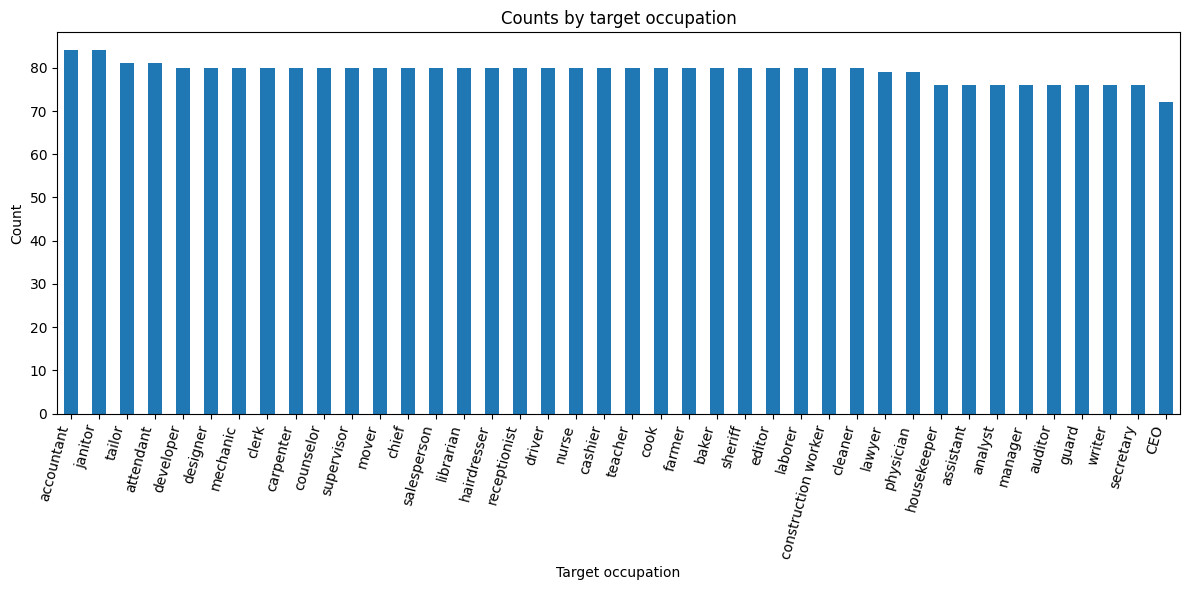

In [14]:
# plot: target job distribution
plt.figure(figsize=(12, 6))
target_counts.sort_values("count", ascending=False).plot(
    x="target", y="count", kind="bar", legend=False, ax=plt.gca()
)
plt.xticks(rotation=75, ha="right")
plt.xlabel("Target occupation")
plt.ylabel("Count")
plt.title("Counts by target occupation")
plt.tight_layout()
plt.show()


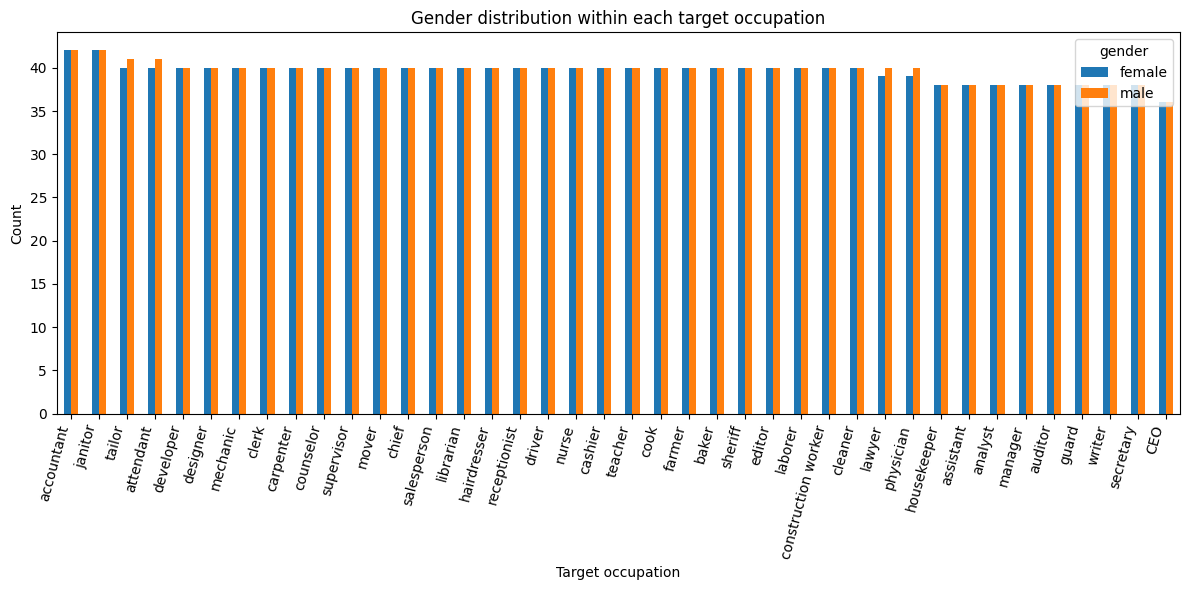

In [15]:
# plot: gender distribution
gender_target_plot = gender_target.loc[target_counts["target"]]
plt.figure(figsize=(12, 6))
gender_target_plot.plot(kind="bar", ax=plt.gca())
plt.xticks(rotation=75, ha="right")
plt.xlabel("Target occupation")
plt.ylabel("Count")
plt.title("Gender distribution within each target occupation")
plt.tight_layout()
plt.show()

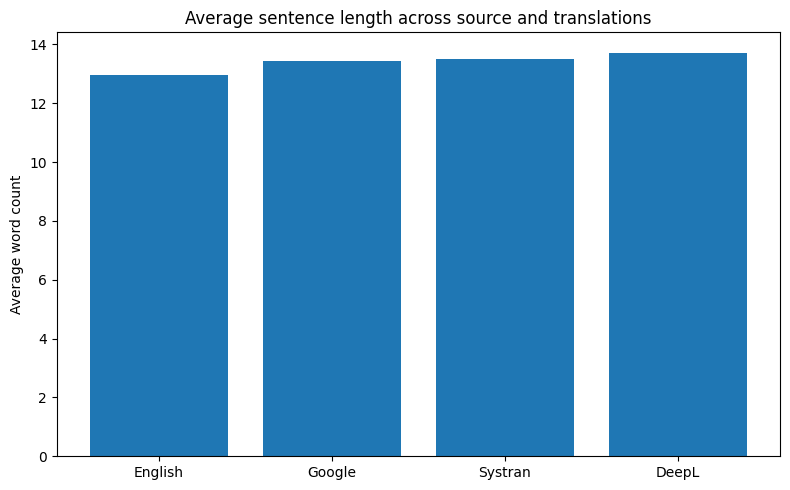

In [16]:
# plot: average sentence length
plt.figure(figsize=(8, 5))
plt.bar(
    ["English", "Google", "Systran", "DeepL"],
    [
        df["text_words"].mean(),
        df["es_googletranslate_words"].mean(),
        df["es_systran_words"].mean(),
        df["es_deepl_words"].mean(),
    ],
)
plt.ylabel("Average word count")
plt.title("Average sentence length across source and translations")
plt.tight_layout()
plt.show()

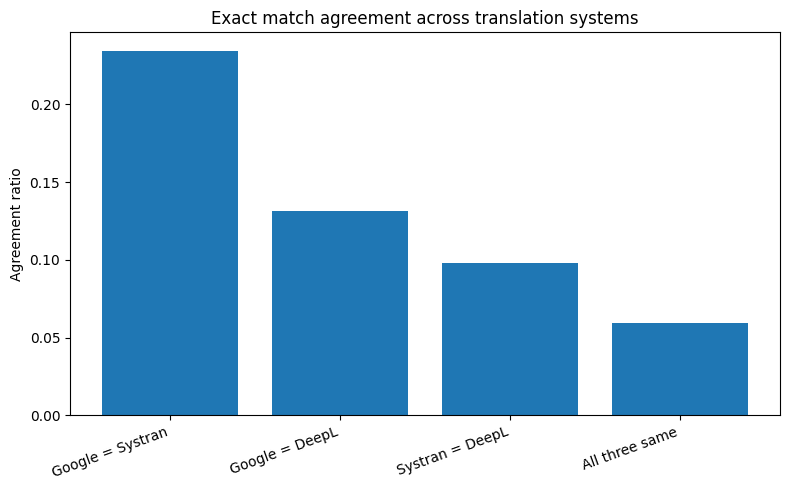

In [17]:
# plot: translate agreement
plt.figure(figsize=(8, 5))
plt.bar(agreement["pair"], agreement["ratio"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Agreement ratio")
plt.title("Exact match agreement across translation systems")
plt.tight_layout()
plt.show()

In [18]:
# gender bias part
import re

In [19]:
# gender marker
masc_markers = {
    "el", "un", "los", "unos"
}

fem_markers = {
    "la", "una", "las", "unas"
}


In [20]:
# tokenize
def tokenize_spanish(text):
    text = str(text).lower()
    tokens = re.findall(r"\b\w+\b", text, flags=re.UNICODE)
    return tokens

# detect gender marker
def detect_gender_markers(text):
    tokens = tokenize_spanish(text)

    has_masc = any(token in masc_markers for token in tokens)
    has_fem = any(token in fem_markers for token in tokens)

    if has_masc and has_fem:
        return "both"
    elif has_masc:
        return "masculine"
    elif has_fem:
        return "feminine"
    else:
        return "unknown"

# give label to three translation
for col in ["es_googletranslate", "es_systran", "es_deepl"]:
    marker_col = col + "_marker"
    df[marker_col] = df[col].apply(detect_gender_markers)

In [21]:
# print result
for col in ["es_googletranslate_marker", "es_systran_marker", "es_deepl_marker"]:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())
    
for col in ["es_googletranslate_marker", "es_systran_marker", "es_deepl_marker"]:
    print(f"\n=== Crosstab: gender vs {col} ===")
    print(pd.crosstab(df["gender"], df[col]))

# take sample
sample_cols = [
    "gender", "target", "text",
    "es_googletranslate", "es_googletranslate_marker",
    "es_systran", "es_systran_marker",
    "es_deepl", "es_deepl_marker"
]

print("\n=== Sample check ===")
print(df[sample_cols].sample(15, random_state=42).to_string(index=False))


=== es_googletranslate_marker ===
es_googletranslate_marker
both         1706
masculine    1175
feminine      283
unknown         4
Name: count, dtype: int64

=== es_systran_marker ===
es_systran_marker
both         1734
masculine    1149
feminine      284
unknown         1
Name: count, dtype: int64

=== es_deepl_marker ===
es_deepl_marker
both         2104
masculine     662
feminine      401
unknown         1
Name: count, dtype: int64

=== Crosstab: gender vs es_googletranslate_marker ===
es_googletranslate_marker  both  feminine  masculine  unknown
gender                                                       
female                     1102       222        258        0
male                        604        61        917        4

=== Crosstab: gender vs es_systran_marker ===
es_systran_marker  both  feminine  masculine  unknown
gender                                               
female             1083       238        261        0
male                651        46        888   

In [22]:
# English target -> possible Spanish forms

TARGET_TO_ES = {
    "developer": {
        "male": {"desarrollador", "desarrolladores"},
        "female": {"desarrolladora", "desarrolladoras"},
        "neutral": set(),
    },
    "designer": {
        "male": {"diseñador", "diseñadores"},
        "female": {"diseñadora", "diseñadoras"},
        "neutral": set(),
    },
    "mechanic": {
        "male": {"mecánico", "mecánicos"},
        "female": {"mecánica", "mecánicas"},
        "neutral": set(),
    },
    "clerk": {
        "male": {"empleado", "empleados", "dependiente"},
        "female": {"empleada", "empleadas", "dependienta"},
        "neutral": {"dependientes"},
    },
    "accountant": {
        "male": {"contador", "contadores"},
        "female": {"contadora", "contadoras"},
        "neutral": set(),
    },
    "attendant": {
        "male": {"empleado", "empleados"},
        "female": {"empleada", "empleadas", "asistenta"},
        "neutral": {"asistente", "asistentes"},
    },
    "auditor": {
        "male": {"auditor", "auditores"},
        "female": {"auditora", "auditoras"},
        "neutral": set(),
    },
    "baker": {
        "male": {"panadero", "panaderos"},
        "female": {"panadera", "panaderas"},
        "neutral": set(),
    },
    "carpenter": {
        "male": {"carpintero", "carpinteros"},
        "female": {"carpintera", "carpinteras"},
        "neutral": set(),
    },
    "cashier": {
        "male": {"cajero", "cajeros"},
        "female": {"cajera", "cajeras"},
        "neutral": set(),
    },
    "ceo": {
        "male": {"director", "directores", "director ejecutivo"},
        "female": {"directora", "directoras", "directora ejecutiva"},
        "neutral": set(),
    },
    "chief": {
        "male": {"jefe", "jefes"},
        "female": {"jefa", "jefas"},
        "neutral": set(),
    },
    "cleaner": {
        "male": {"limpiador", "limpiadores"},
        "female": {"limpiadora", "limpiadoras"},
        "neutral": set(),
    },
    "construction worker": {
        "male": {"obrero", "obreros", "trabajador", "trabajadores"},
        "female": {"obrera", "obreras", "trabajadora", "trabajadoras"},
        "neutral": set(),
    },
    "counselor": {
        "male": {"consejero", "consejeros"},
        "female": {"consejera", "consejeras"},
        "neutral": set(),
    },
    "driver": {
        "male": {"conductor", "conductores"},
        "female": {"conductora", "conductoras"},
        "neutral": set(),
    },
    "editor": {
        "male": {"editor", "editores"},
        "female": {"editora", "editoras"},
        "neutral": set(),
    },
    "farmer": {
        "male": {"granjero", "granjeros", "agricultor", "agricultores"},
        "female": {"granjera", "granjeras", "agricultora", "agricultoras"},
        "neutral": set(),
    },
    "guard": {
        "male": set(),
        "female": set(),
        "neutral": {"guardia", "guardias", "vigilante", "vigilantes"},
    },
    "janitor": {
        "male": set(),
        "female": set(),
        "neutral": {"conserje", "conserjes"},
    },
    "laborer": {
        "male": {"obrero", "obreros", "trabajador", "trabajadores"},
        "female": {"obrera", "obreras", "trabajadora", "trabajadoras"},
        "neutral": set(),
    },
    "physician": {
        "male": {"médico", "médicos"},
        "female": {"médica", "médicas"},
        "neutral": set(),
    },
    "receptionist": {
        "male": set(),
        "female": set(),
        "neutral": {"recepcionista", "recepcionistas"},
    },
    "secretary": {
        "male": {"secretario", "secretarios"},
        "female": {"secretaria", "secretarias"},
        "neutral": set(),
    },
    "sheriff": {
        "male": set(),
        "female": set(),
        "neutral": {"sheriff", "sheriffs", "alguacil", "alguaciles"},
    },
    "supervisor": {
        "male": {"supervisor", "supervisores"},
        "female": {"supervisora", "supervisoras"},
        "neutral": set(),
    },
    "tailor": {
        "male": {"sastre", "sastres"},
        "female": {"modista"},
        "neutral": {"modistas"},
    },
    "analyst": {
        "male": set(),
        "female": set(),
        "neutral": {"analista", "analistas"},
    },
    "assistant": {
        "male": set(),
        "female": {"asistenta"},
        "neutral": {"asistente", "asistentes"},
    },
    "cook": {
        "male": {"cocinero", "cocineros"},
        "female": {"cocinera", "cocineras"},
        "neutral": {"chef"},
    },
    "hairdresser": {
        "male": {"peluquero", "peluqueros"},
        "female": {"peluquera", "peluqueras"},
        "neutral": set(),
    },
    "housekeeper": {
        "male": set(),
        "female": {"ama de llaves", "amas de llaves"},
        "neutral": set(),
    },
    "lawyer": {
        "male": {"abogado", "abogados"},
        "female": {"abogada", "abogadas"},
        "neutral": set(),
    },
    "librarian": {
        "male": {"bibliotecario", "bibliotecarios"},
        "female": {"bibliotecaria", "bibliotecarias"},
        "neutral": set(),
    },
    "manager": {
        "male": {"jefe", "jefes"},
        "female": {"jefa", "gerenta"},
        "neutral": {"gerente", "gerentes"},
    },
    "mover": {
        "male": {"mudancero", "mudanceros"},
        "female": {"mudancera", "mudanceras"},
        "neutral": {"transportista", "transportistas"},
    },
    "nurse": {
        "male": {"enfermero", "enfermeros"},
        "female": {"enfermera", "enfermeras"},
        "neutral": set(),
    },
    "salesperson": {
        "male": {"vendedor", "vendedores"},
        "female": {"vendedora", "vendedoras"},
        "neutral": set(),
    },
    "teacher": {
        "male": {"profesor", "profesores", "maestro", "maestros"},
        "female": {"profesora", "profesoras", "maestra", "maestras"},
        "neutral": set(),
    },
    "writer": {
        "male": {"escritor", "escritores"},
        "female": {"escritora", "escritoras"},
        "neutral": set(),
    },
}

# Conservative suffix rules
# Only used as weak fallback
STRONG_SUFFIX_RULES = [
    ("adoras", "female"),
    ("adora", "female"),
    ("adores", "male"),
    ("ador", "male"),

    ("edoras", "female"),
    ("edora", "female"),
    ("edores", "male"),
    ("edor", "male"),

    ("eras", "female"),
    ("era", "female"),
    ("eros", "male"),
    ("ero", "male"),

    ("arias", "female"),
    ("aria", "female"),
    ("arios", "male"),
    ("ario", "male"),
]

WEAK_SUFFIX_RULES = [
    ("oras", "female"),
    ("ora", "female"),
    ("ores", "male"),
    ("or", "male"),
]


In [23]:
# Normalize gender labels
def normalize_gender_label(value):
    if value is None:
        return "unknown"

    x = str(value).strip().lower()
    if x in {"male", "m", "masc", "masculine"}:
        return "male"
    if x in {"female", "f", "fem", "feminine"}:
        return "female"
    return "unknown"


def infer_gender_from_suffix(word, allow_weak=True):
    word = str(word).strip().lower()

    for suffix, gender in STRONG_SUFFIX_RULES:
        if word.endswith(suffix):
            return gender

    if allow_weak:
        for suffix, gender in WEAK_SUFFIX_RULES:
            if word.endswith(suffix):
                return gender

    return "unknown"

# Helper: get determiner on the left
def get_left_determiner(token):
    for left_tok in token.lefts:
        if left_tok.dep_ == "det" or left_tok.pos_ == "DET":
            return left_tok.text.lower()
    return ""

# Weak contextual inference
#    Used only when lexicon match is neutral
def infer_gender_from_token_context(token):
    article_text = get_left_determiner(token)

    # token morphology first
    token_gender = set(token.morph.get("Gender"))
    if "Masc" in token_gender:
        return "male", article_text, "token_morph"
    if "Fem" in token_gender:
        return "female", article_text, "token_morph"

    # article morphology next
    if article_text:
        art_doc = nlp(article_text)
        if len(art_doc) > 0:
            article_gender = set(art_doc[0].morph.get("Gender"))
            if "Masc" in article_gender:
                return "male", article_text, "article_morph"
            if "Fem" in article_gender:
                return "female", article_text, "article_morph"

    # article lookup fallback
    if article_text in {"el", "un", "los", "unos"}:
        return "male", article_text, "article_lookup"
    if article_text in {"la", "una", "las", "unas"}:
        return "female", article_text, "article_lookup"

    # very conservative suffix fallback
    suffix_gender = infer_gender_from_suffix(token.text)
    if suffix_gender != "unknown":
        return suffix_gender, article_text, "suffix_rule"

    return "unknown", article_text, "unresolved"

# Main role finder
def find_target_role_in_spanish(spanish_sentence, english_target, target_to_es):
    target_norm = str(english_target).strip().lower()

    if pd.isna(spanish_sentence) or str(spanish_sentence).strip() == "":
        return {
            "matched_role": "",
            "evidence_phrase": "",
            "detected_gender": "unknown",
            "evidence_source": "empty_translation",
            "note": "Empty translation"
        }

    if target_norm not in target_to_es:
        return {
            "matched_role": "",
            "evidence_phrase": "",
            "detected_gender": "unknown",
            "evidence_source": "target_missing_in_lexicon",
            "note": f"Target '{english_target}' not found in TARGET_TO_ES"
        }

    lex = target_to_es[target_norm]
    male_forms = {x.lower() for x in lex["male"]}
    female_forms = {x.lower() for x in lex["female"]}
    neutral_forms = {x.lower() for x in lex["neutral"]}
    all_forms = male_forms | female_forms | neutral_forms

    doc = nlp(str(spanish_sentence))

    # Pass 1: exact token / lemma match
    for token in doc:
        token_text = token.text.lower()
        token_lemma = token.lemma_.lower()

        matched = None
        if token_text in all_forms:
            matched = token_text
        elif token_lemma in all_forms:
            matched = token_lemma

        if matched is None:
            continue

        article_text = get_left_determiner(token)
        evidence_phrase = f"{article_text} {token.text}".strip().lower()

        if matched in male_forms:
            return {
                "matched_role": token.text,
                "evidence_phrase": evidence_phrase,
                "detected_gender": "male",
                "evidence_source": "lexicon_direct",
                "note": ""
            }

        if matched in female_forms:
            return {
                "matched_role": token.text,
                "evidence_phrase": evidence_phrase,
                "detected_gender": "female",
                "evidence_source": "lexicon_direct",
                "note": ""
            }

        # matched neutral form -> optionally inspect local context
        if matched in neutral_forms:
            ctx_gender, ctx_article, ctx_source = infer_gender_from_token_context(token)

            if ctx_gender in {"male", "female"}:
                evidence_phrase = f"{ctx_article} {token.text}".strip().lower()
                return {
                    "matched_role": token.text,
                    "evidence_phrase": evidence_phrase,
                    "detected_gender": ctx_gender,
                    "evidence_source": f"neutral_form_with_{ctx_source}",
                    "note": "Gender inferred from local context around neutral profession form"
                }

            return {
                "matched_role": token.text,
                "evidence_phrase": evidence_phrase,
                "detected_gender": "unknown",
                "evidence_source": "lexicon_neutral",
                "note": "Matched neutral/invariant profession form"
            }

    # Pass 2: multi-word phrase match
    sent_lower = str(spanish_sentence).lower()
    for form in sorted(all_forms, key=len, reverse=True):
        if " " not in form:
            continue
        if form not in sent_lower:
            continue

        if form in male_forms:
            detected_gender = "male"
        elif form in female_forms:
            detected_gender = "female"
        else:
            detected_gender = "unknown"

        return {
            "matched_role": form,
            "evidence_phrase": form,
            "detected_gender": detected_gender,
            "evidence_source": "lexicon_phrase_match",
            "note": "" if detected_gender != "unknown" else "Matched neutral/invariant multi-word profession"
        }

    return {
        "matched_role": "",
        "evidence_phrase": "",
        "detected_gender": "unknown",
        "evidence_source": "no_match",
        "note": f"No Spanish profession found for target '{english_target}'"
    }

# Audit one row
def audit_translation_row(spanish_sentence, target, gold_gender, target_to_es=TARGET_TO_ES):
    gold_gender_norm = normalize_gender_label(gold_gender)

    role_result = find_target_role_in_spanish(
        spanish_sentence=spanish_sentence,
        english_target=target,
        target_to_es=target_to_es
    )

    detected_gender_norm = normalize_gender_label(role_result["detected_gender"])

    if role_result["evidence_phrase"]:
        linguistic_evidence = (
            f"{role_result['evidence_phrase']} -> {detected_gender_norm} "
            f"({role_result['evidence_source']})"
        )
    else:
        linguistic_evidence = "target role not found or gender could not be resolved"

    if gold_gender_norm == "unknown":
        audit_status = "INVALID_GOLD_GENDER"
    elif detected_gender_norm == "unknown":
        audit_status = "UNRESOLVED"
    elif detected_gender_norm == gold_gender_norm:
        audit_status = "CONSISTENT"
    else:
        audit_status = "GENDER MISMATCH"

    return {
        "Matched_Role": role_result["matched_role"],
        "Detected_Gender": detected_gender_norm,
        "Evidence_Source": role_result["evidence_source"],
        "Linguistic_Evidence": linguistic_evidence,
        "Audit_Status": audit_status,
        "Note": role_result["note"]
    }

# Audit one system column
def audit_one_system(df, translation_col, target_to_es=TARGET_TO_ES):
    required_cols = {"gender", "target", translation_col}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    results = []

    for _, row in df.iterrows():
        result = audit_translation_row(
            spanish_sentence=row[translation_col],
            target=row["target"],
            gold_gender=row["gender"],
            target_to_es=target_to_es
        )
        results.append(result)

    result_df = pd.DataFrame(results).rename(columns={
        "Matched_Role": f"{translation_col}_matched_role",
        "Detected_Gender": f"{translation_col}_detected_gender",
        "Evidence_Source": f"{translation_col}_evidence_source",
        "Linguistic_Evidence": f"{translation_col}_evidence",
        "Audit_Status": f"{translation_col}_status",
        "Note": f"{translation_col}_note"
    })

    return result_df

# Audit multiple systems
def audit_all_systems(df, translation_cols, target_to_es=TARGET_TO_ES):
    output_df = df.copy().reset_index(drop=True)

    for col in translation_cols:
        result_df = audit_one_system(output_df, col, target_to_es=target_to_es)
        output_df = pd.concat([output_df, result_df], axis=1)

    return output_df

# Coverage check
def find_missing_targets(df, target_to_es=TARGET_TO_ES):
    all_targets = sorted(df["target"].dropna().astype(str).str.lower().unique())
    missing_targets = [t for t in all_targets if t not in target_to_es]
    return missing_targets

# Summary table

def summarize_audit_results(df, translation_cols):
    summaries = []

    for col in translation_cols:
        status_col = f"{col}_status"
        if status_col not in df.columns:
            continue

        counts = df[status_col].value_counts(dropna=False).to_dict()

        summaries.append({
            "system": col,
            "consistent": counts.get("CONSISTENT", 0),
            "mismatch": counts.get("GENDER MISMATCH", 0),
            "unresolved": counts.get("UNRESOLVED", 0),
            "invalid_gold": counts.get("INVALID_GOLD_GENDER", 0),
            "total": len(df),
            "coverage_rate": (len(df) - counts.get("UNRESOLVED", 0)) / len(df),
            "mismatch_rate_over_all": counts.get("GENDER MISMATCH", 0) / len(df),
            "mismatch_rate_over_resolved": (
                counts.get("GENDER MISMATCH", 0) /
                max(1, len(df) - counts.get("UNRESOLVED", 0) - counts.get("INVALID_GOLD_GENDER", 0))
            ),
        })

    return pd.DataFrame(summaries)

In [24]:
translation_cols = ["es_googletranslate", "es_systran", "es_deepl"]

missing_targets = find_missing_targets(df, TARGET_TO_ES)
print("Missing targets:", missing_targets)

audit_df = audit_all_systems(df, translation_cols, TARGET_TO_ES)

summary_df = summarize_audit_results(audit_df, translation_cols)
print(summary_df)

# evidence source
for col in translation_cols:
    source_col = f"{col}_evidence_source"
    print(f"\n=== {source_col} ===")
    print(audit_df[source_col].value_counts(dropna=False))

Missing targets: []
               system  consistent  mismatch  unresolved  invalid_gold  total  \
0  es_googletranslate        2105       756         307             0   3168   
1          es_systran        1996       795         377             0   3168   
2            es_deepl        2026       773         369             0   3168   

   coverage_rate  mismatch_rate_over_all  mismatch_rate_over_resolved  
0       0.903093                0.238636                     0.264243  
1       0.880997                0.250947                     0.284844  
2       0.883523                0.244003                     0.276170  

=== es_googletranslate_evidence_source ===
es_googletranslate_evidence_source
lexicon_direct                     2335
neutral_form_with_article_morph     322
lexicon_neutral                     176
no_match                            131
neutral_form_with_token_morph       128
lexicon_phrase_match                 76
Name: count, dtype: int64

=== es_systran_evidence_s

In [25]:
def make_pro_anti_summary_table(final_report):
    systems = ["es_googletranslate", "es_systran", "es_deepl"]
    system_names = {
        "es_googletranslate": "googletranslate",
        "es_systran": "systran",
        "es_deepl": "deepl"
    }

    row_order = [
        "pro-stereotype correct%",
        "pro-stereotype incorrect%",
        "pro-stereotype unresolved%",
        "anti-stereotype correct%",
        "anti-stereotype incorrect%",
        "anti-stereotype unresolved%",
    ]

    result = pd.DataFrame(index=row_order, columns=[system_names[s] for s in systems])

    label_map = {
        "pro": "pro-stereotype",
        "anti": "anti-stereotype"
    }

    for sys in systems:
        status_col = f"{sys}_status"
        out_col = system_names[sys]

        for label_value, label_name in label_map.items():
            subset = final_report[final_report["label"] == label_value]
            total = len(subset)

            if total == 0:
                result.loc[f"{label_name} correct%", out_col] = ""
                result.loc[f"{label_name} incorrect%", out_col] = ""
                result.loc[f"{label_name} unresolved%", out_col] = ""
                continue

            counts = subset[status_col].value_counts()

            correct_pct = counts.get("CONSISTENT", 0) / total * 100
            incorrect_pct = counts.get("GENDER MISMATCH", 0) / total * 100
            unresolved_pct = counts.get("UNRESOLVED", 0) / total * 100

            result.loc[f"{label_name} correct%", out_col] = f"{correct_pct:.2f}%"
            result.loc[f"{label_name} incorrect%", out_col] = f"{incorrect_pct:.2f}%"
            result.loc[f"{label_name} unresolved%", out_col] = f"{unresolved_pct:.2f}%"

    return result

summary_table = make_pro_anti_summary_table(audit_df)
print(summary_table.to_string())

                            googletranslate systran   deepl
pro-stereotype correct%              80.43%  73.99%  82.39%
pro-stereotype incorrect%            10.73%  14.46%   6.69%
pro-stereotype unresolved%            8.84%  11.55%  10.92%
anti-stereotype correct%             52.46%  52.02%  45.52%
anti-stereotype incorrect%           36.99%  35.73%  42.11%
anti-stereotype unresolved%          10.54%  12.25%  12.37%


In [26]:
SYSTEMS = ["es_googletranslate", "es_systran", "es_deepl"]
SYSTEM_LABELS = {
    "es_googletranslate": "Google",
    "es_systran": "Systran",
    "es_deepl": "DeepL"
}

STATUS_ORDER = ["CONSISTENT", "GENDER MISMATCH", "UNRESOLVED"]
STATUS_LABELS = {
    "CONSISTENT": "Correct",
    "GENDER MISMATCH": "Mismatch",
    "UNRESOLVED": "Unresolved"
}

def annotate_grouped_bars(ax, pivot_df, denominator_series=None, rate_mode=False):
    """
    If rate_mode=False:
        annotate as count + percent using denominator_series[row]
    If rate_mode=True:
        annotate as percent only from bar height
    """
    n_rows = pivot_df.shape[0]
    n_cols = pivot_df.shape[1]

    for i, container in enumerate(ax.containers):
        for j, bar in enumerate(container):
            height = bar.get_height()
            if pd.isna(height):
                continue

            if rate_mode:
                label = f"{height:.1%}"
            else:
                row_name = pivot_df.index[j]
                denom = denominator_series[row_name] if denominator_series is not None else 0
                pct = (height / denom) if denom else 0
                label = f"{int(height)}\n({pct:.1%})"

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                label,
                ha="center",
                va="bottom",
                fontsize=9
            )

# 1) Overall counts for 3 MT systems in one plot
def plot_overall_status_counts(audit_df):
    rows = []
    denominators = {}

    for sys in SYSTEMS:
        status_col = f"{sys}_status"
        system_name = SYSTEM_LABELS[sys]
        counts = audit_df[status_col].value_counts()
        denominators[system_name] = len(audit_df)

        for status in STATUS_ORDER:
            rows.append({
                "system": system_name,
                "status": STATUS_LABELS[status],
                "count": counts.get(status, 0)
            })

    plot_df = pd.DataFrame(rows)
    pivot_df = plot_df.pivot(index="system", columns="status", values="count").fillna(0)
    pivot_df = pivot_df[["Correct", "Mismatch", "Unresolved"]]

    ax = pivot_df.plot(kind="bar", figsize=(10, 6))
    plt.title("Overall Audit Results Across 3 MT Systems")
    plt.xlabel("MT System")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.legend(title="Result")
    annotate_grouped_bars(ax, pivot_df, denominator_series=denominators, rate_mode=False)
    plt.tight_layout()
    plt.show()

# 2) Pro / Anti plot
def plot_status_counts_by_label(audit_df, label_value):
    subset = audit_df[audit_df["label"] == label_value].copy()

    rows = []
    denominators = {}

    for sys in SYSTEMS:
        status_col = f"{sys}_status"
        system_name = SYSTEM_LABELS[sys]
        counts = subset[status_col].value_counts()
        denominators[system_name] = len(subset)

        for status in STATUS_ORDER:
            rows.append({
                "system": system_name,
                "status": STATUS_LABELS[status],
                "count": counts.get(status, 0)
            })

    plot_df = pd.DataFrame(rows)
    pivot_df = plot_df.pivot(index="system", columns="status", values="count").fillna(0)
    pivot_df = pivot_df[["Correct", "Mismatch", "Unresolved"]]

    ax = pivot_df.plot(kind="bar", figsize=(10, 6))
    plt.title(f'Audit Results for "{label_value}" Samples')
    plt.xlabel("MT System")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.legend(title="Result")
    annotate_grouped_bars(ax, pivot_df, denominator_series=denominators, rate_mode=False)
    plt.tight_layout()
    plt.show()

# 3) Top 10 targets with highest mismatch rate for each MT system
def plot_top10_mismatch_rate_per_system(audit_df, top_n=10):
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))

    for ax, sys in zip(axes, SYSTEMS):
        status_col = f"{sys}_status"

        temp = audit_df.groupby("target")[status_col].agg(
            total="count",
            mismatch=lambda x: (x == "GENDER MISMATCH").sum()
        ).reset_index()

        temp["mismatch_rate"] = temp["mismatch"] / temp["total"]
        top_df = temp.sort_values(["mismatch_rate", "mismatch"], ascending=[False, False]).head(top_n)

        bars = ax.bar(top_df["target"], top_df["mismatch_rate"])
        ax.set_title(f"Top {top_n} Mismatch Rate - {SYSTEM_LABELS[sys]}")
        ax.set_xlabel("Target")
        ax.set_ylabel("Mismatch Rate")
        ax.tick_params(axis="x", rotation=75)

        for bar, mismatch, total, rate in zip(bars, top_df["mismatch"], top_df["total"], top_df["mismatch_rate"]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{rate:.1%}\n({mismatch}/{total})",
                ha="center",
                va="bottom",
                fontsize=8
            )

    plt.tight_layout()
    plt.show()

# 4) Top 10 targets with most unresolved cases for each MT system
def plot_top10_unresolved_per_system(audit_df, top_n=10):
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))

    for ax, sys in zip(axes, SYSTEMS):
        status_col = f"{sys}_status"

        temp = audit_df.groupby("target")[status_col].agg(
            total="count",
            unresolved=lambda x: (x == "UNRESOLVED").sum()
        ).reset_index()

        temp["unresolved_rate"] = temp["unresolved"] / temp["total"]
        top_df = temp.sort_values(["unresolved", "unresolved_rate"], ascending=[False, False]).head(top_n)

        bars = ax.bar(top_df["target"], top_df["unresolved_rate"])
        ax.set_title(f"Top {top_n} Unresolved Targets - {SYSTEM_LABELS[sys]}")
        ax.set_xlabel("Target")
        ax.set_ylabel("Unresolved Rate")
        ax.tick_params(axis="x", rotation=75)

        for bar, unresolved, total, rate in zip(bars, top_df["unresolved"], top_df["total"], top_df["unresolved_rate"]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{rate:.1%}\n({unresolved}/{total})",
                ha="center",
                va="bottom",
                fontsize=8
            )

    plt.tight_layout()
    plt.show()

# 5) Top 10 targets with highest mismatch rate across all 3 systems
def plot_top10_mismatch_rate_all_systems(audit_df, top_n=10):
    rows = []

    for target, group in audit_df.groupby("target"):
        total_cases = len(group) * len(SYSTEMS)
        mismatch_count = 0

        for sys in SYSTEMS:
            status_col = f"{sys}_status"
            mismatch_count += (group[status_col] == "GENDER MISMATCH").sum()

        mismatch_rate = mismatch_count / total_cases if total_cases > 0 else 0

        rows.append({
            "target": target,
            "mismatch_count": mismatch_count,
            "total_cases": total_cases,
            "mismatch_rate": mismatch_rate
        })

    result_df = pd.DataFrame(rows)
    top_df = result_df.sort_values(
        ["mismatch_rate", "mismatch_count"], ascending=[False, False]
    ).head(top_n)

    bars = plt.bar(top_df["target"], top_df["mismatch_rate"])
    plt.figure(figsize=(12, 7))
    plt.clf()

    fig, ax = plt.subplots(figsize=(12, 7))
    bars = ax.bar(top_df["target"], top_df["mismatch_rate"])

    ax.set_title(f"Top {top_n} Targets with Highest Mismatch Rate Across All 3 Systems")
    ax.set_xlabel("Target")
    ax.set_ylabel("Mismatch Rate")
    ax.tick_params(axis="x", rotation=75)

    for bar, mismatch_count, total_cases, mismatch_rate in zip(
        bars, top_df["mismatch_count"], top_df["total_cases"], top_df["mismatch_rate"]
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{mismatch_rate:.1%}\n({mismatch_count}/{total_cases})",
            ha="center",
            va="bottom",
            fontsize=8
        )

    plt.tight_layout()
    plt.show()

    return top_df

# tables for checking
def get_top10_mismatch_rate_per_system_table(audit_df, top_n=10):
    out = {}
    for sys in SYSTEMS:
        status_col = f"{sys}_status"
        temp = audit_df.groupby("target")[status_col].agg(
            total="count",
            mismatch=lambda x: (x == "GENDER MISMATCH").sum()
        ).reset_index()
        temp["mismatch_rate"] = temp["mismatch"] / temp["total"]
        out[sys] = temp.sort_values(["mismatch_rate", "mismatch"], ascending=[False, False]).head(top_n)
    return out


def get_top10_unresolved_per_system_table(audit_df, top_n=10):
    out = {}
    for sys in SYSTEMS:
        status_col = f"{sys}_status"
        temp = audit_df.groupby("target")[status_col].agg(
            total="count",
            unresolved=lambda x: (x == "UNRESOLVED").sum()
        ).reset_index()
        temp["unresolved_rate"] = temp["unresolved"] / temp["total"]
        out[sys] = temp.sort_values(["unresolved", "unresolved_rate"], ascending=[False, False]).head(top_n)
    return out



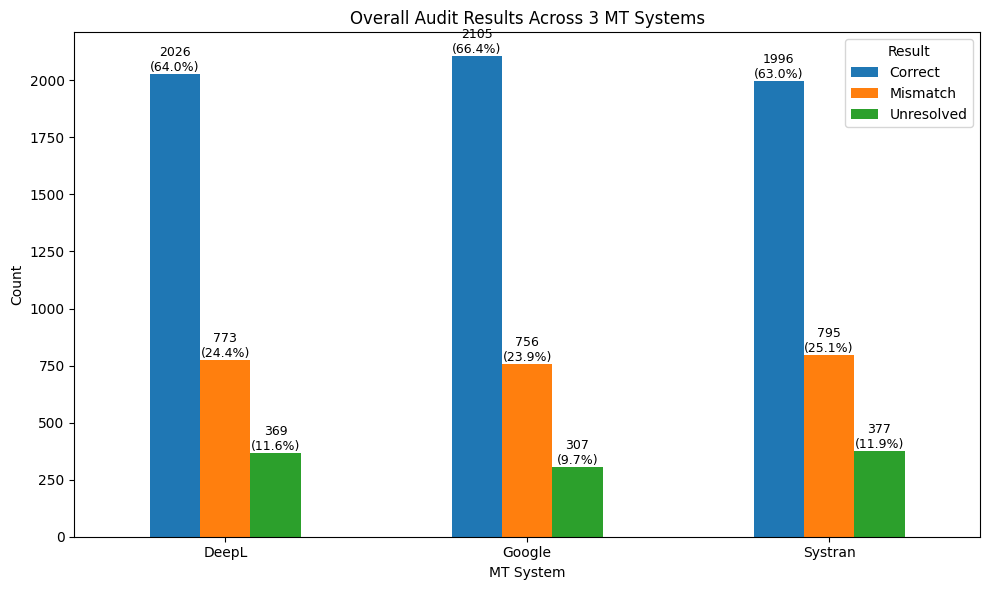

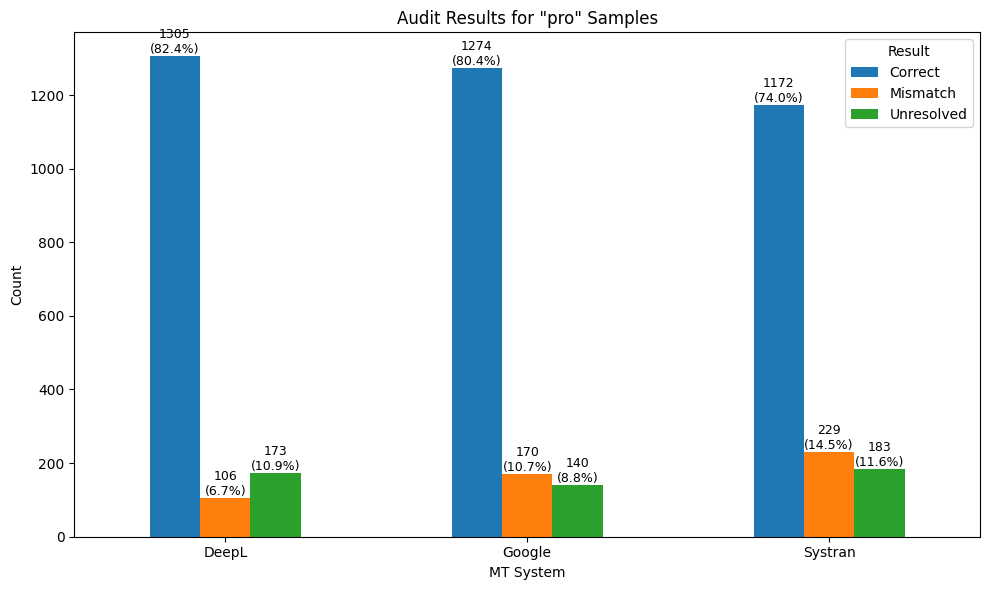

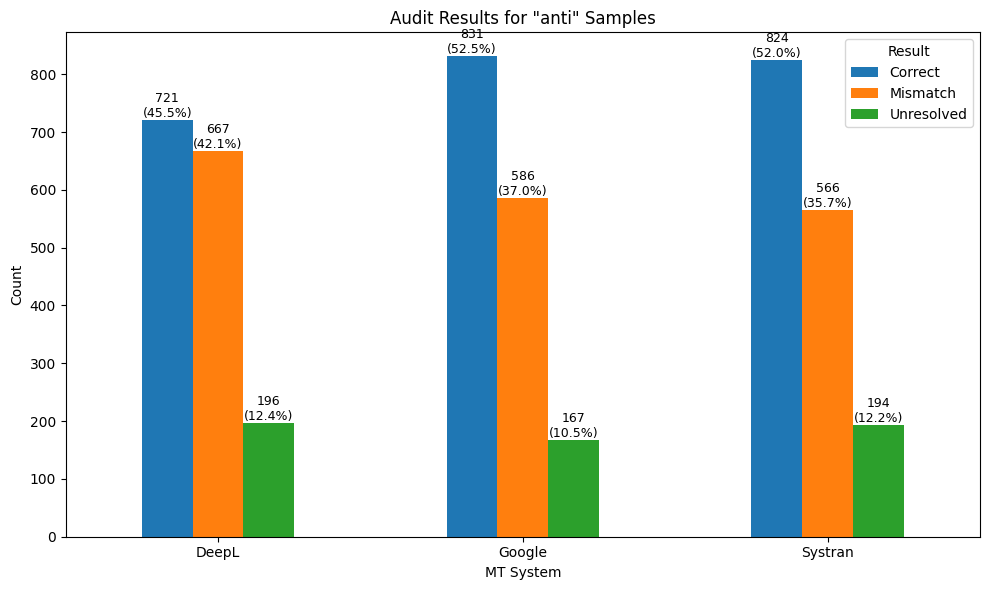

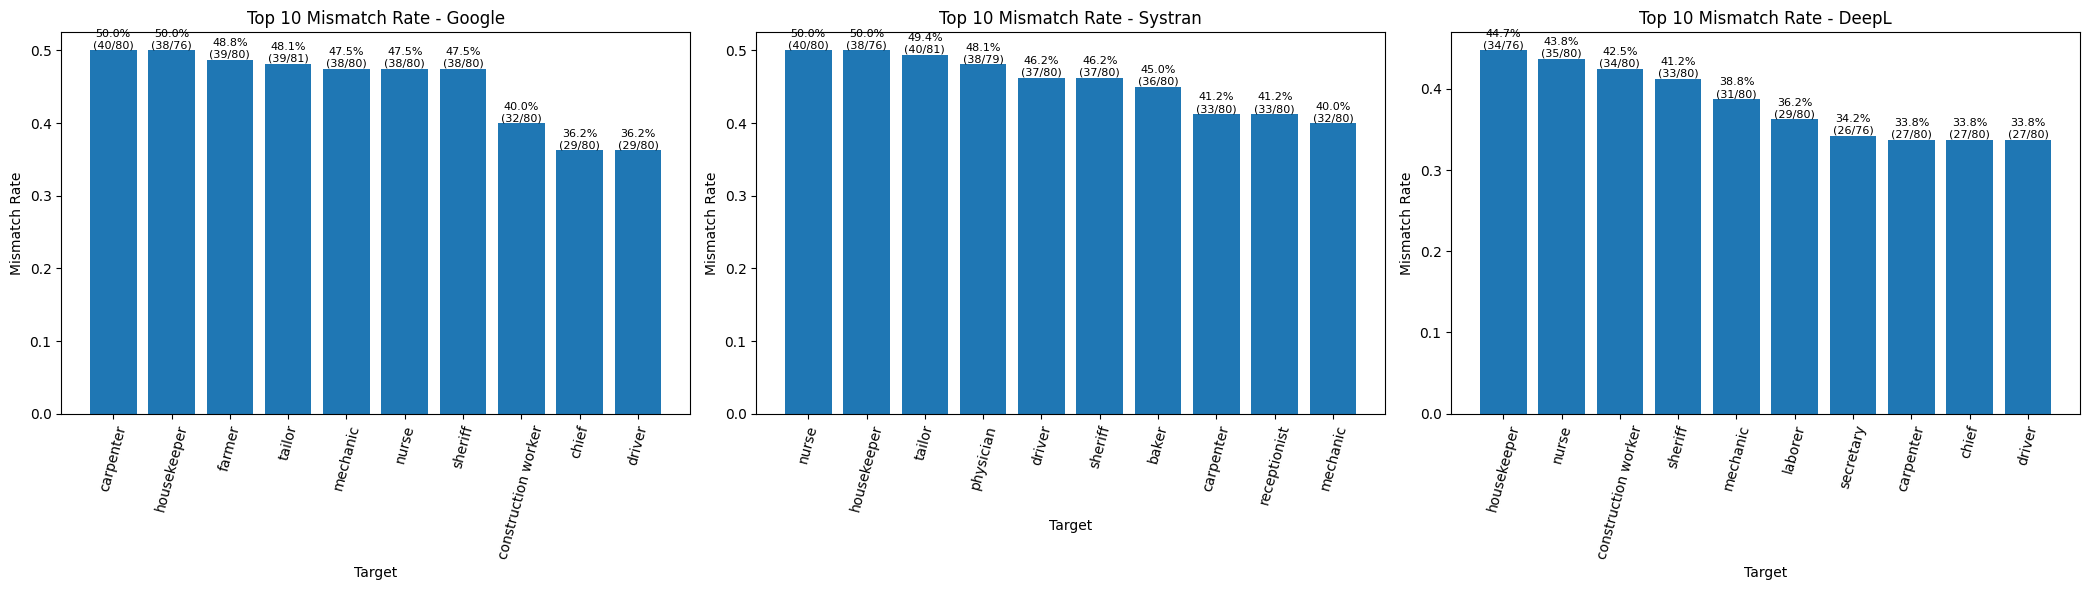

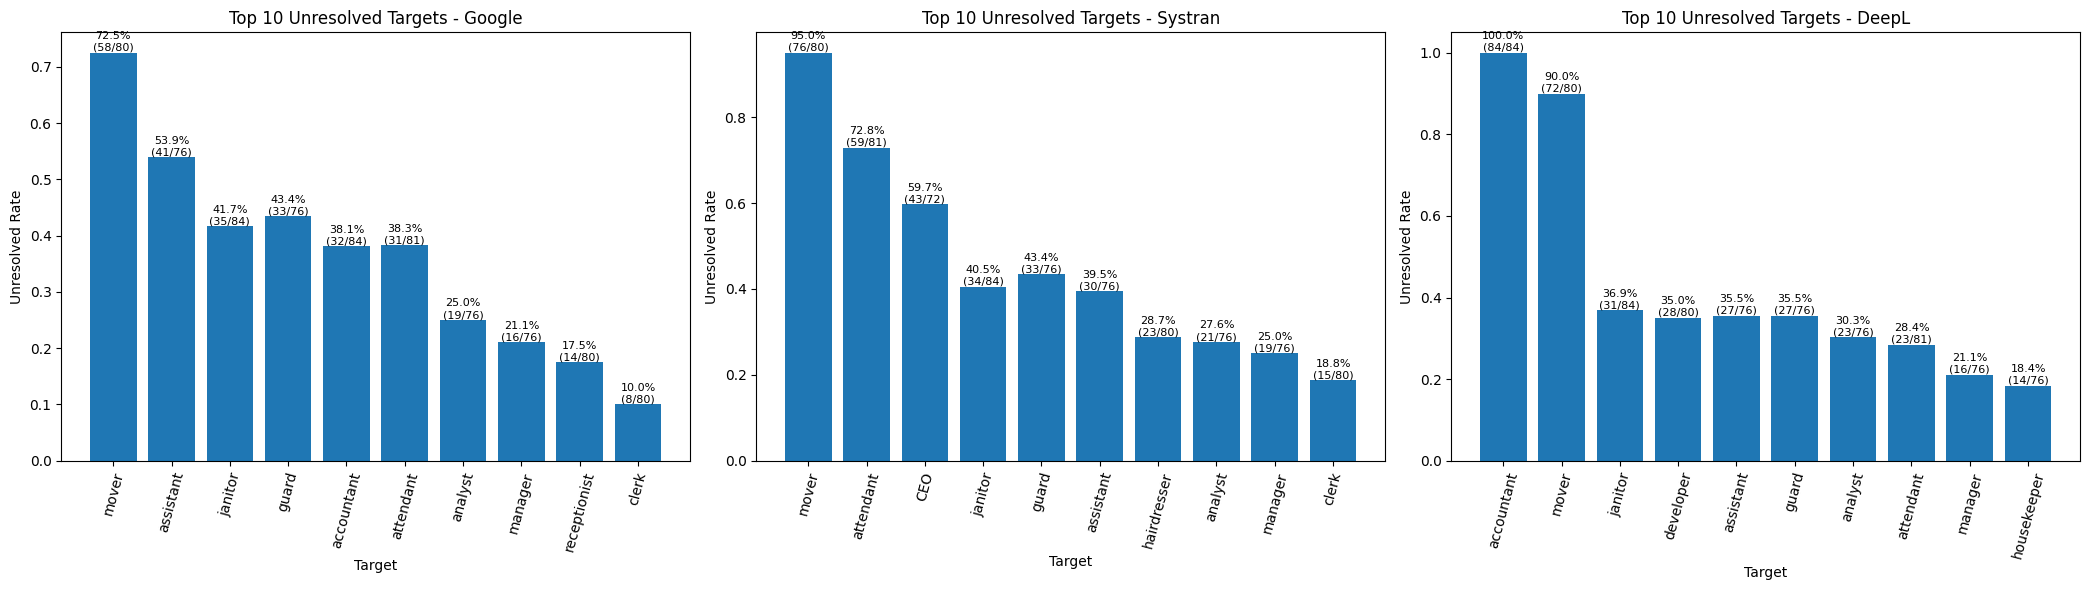

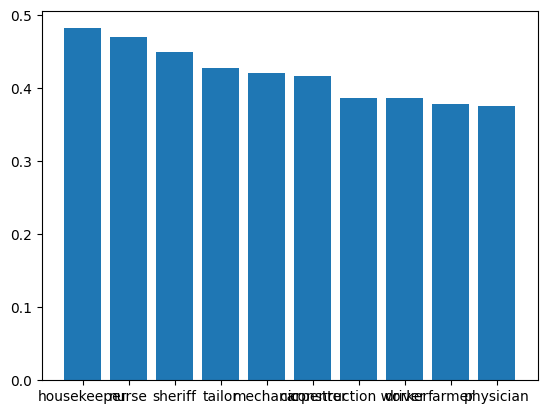

<Figure size 1200x700 with 0 Axes>

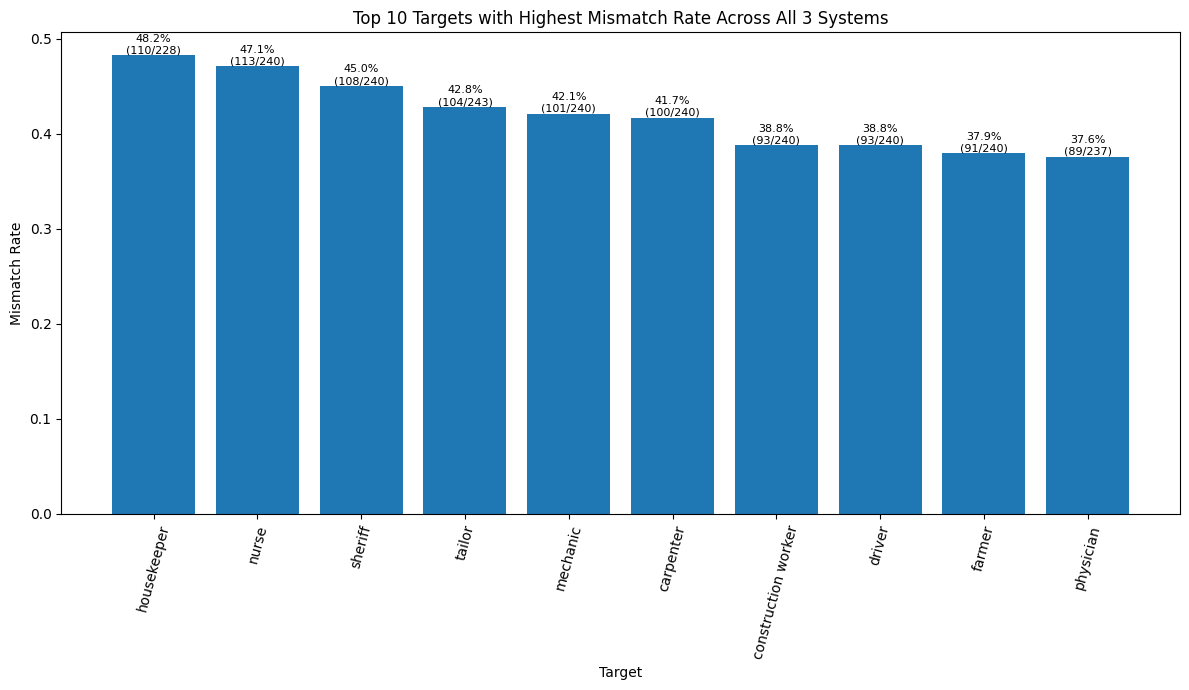

             target  mismatch_count  total_cases  mismatch_rate
        housekeeper             110          228       0.482456
              nurse             113          240       0.470833
            sheriff             108          240       0.450000
             tailor             104          243       0.427984
           mechanic             101          240       0.420833
          carpenter             100          240       0.416667
construction worker              93          240       0.387500
             driver              93          240       0.387500
             farmer              91          240       0.379167
          physician              89          237       0.375527


In [27]:
plot_overall_status_counts(audit_df)

plot_status_counts_by_label(audit_df, "pro")
plot_status_counts_by_label(audit_df, "anti")

plot_top10_mismatch_rate_per_system(audit_df, top_n=10)
plot_top10_unresolved_per_system(audit_df, top_n=10)

top10_all_systems_df = plot_top10_mismatch_rate_all_systems(audit_df, top_n=10)
print(top10_all_systems_df.to_string(index=False))

In [28]:
# combine the col 
def build_modeling_df(audit_df):
    rows = []

    for sys in SYSTEMS:
        status_col = f"{sys}_status"

        temp = audit_df[[
            "text", "target", "gender", "label", "idx",
            sys, status_col
        ]].copy()

        temp = temp.rename(columns={
            "text": "english_text",
            sys: "spanish_text",
            status_col: "audit_status"
        })

        temp["system"] = sys
        rows.append(temp)

    model_df = pd.concat(rows, axis=0, ignore_index=True)

    # only keep clean supervised cases for first baseline
    model_df = model_df[model_df["audit_status"].isin(["CONSISTENT", "GENDER MISMATCH"])].copy()

    # binary label
    model_df["y"] = (model_df["audit_status"] == "GENDER MISMATCH").astype(int)

    return model_df.reset_index(drop=True)

model_df = build_modeling_df(audit_df)

print(model_df.shape)
print(model_df["audit_status"].value_counts())
print(model_df["system"].value_counts())
print(model_df.head())

(8451, 9)
audit_status
CONSISTENT         6127
GENDER MISMATCH    2324
Name: count, dtype: int64
system
es_googletranslate    2861
es_deepl              2799
es_systran            2791
Name: count, dtype: int64
                                        english_text       target  gender  \
0  The developer argued with the designer because...    developer  female   
1  The developer argued with the designer because...     designer    male   
2  The mechanic gave the clerk a present because ...     mechanic  female   
3  The mechanic gave the clerk a present because ...        clerk    male   
4  The mover said thank you to the housekeeper be...  housekeeper    male   

  label  idx                                       spanish_text  \
0  anti    1  El desarrollador discutió con el diseñador por...   
1  anti    5  El desarrollador discutió con el diseñador por...   
2  anti    1  El mecánico le dio un regalo a la empleada por...   
3  anti    4  El mecánico le dio un regalo al empleado por

In [29]:
# combined the text togther
def make_combined_text(df):
    return (
        "target=" + df["target"].astype(str) +
        " gender=" + df["gender"].astype(str) +
        " label=" + df["label"].astype(str) +
        " idx=" + df["idx"].astype(str) +
        " english=" + df["english_text"].astype(str) +
        " spanish=" + df["spanish_text"].astype(str)
    )

# check
model_df["combined_text"] = make_combined_text(model_df)
print(model_df["combined_text"].iloc[0])

target=developer gender=female label=anti idx=1 english=The developer argued with the designer because she did not like the design. spanish=El desarrollador discutió con el diseñador porque no le gustaba el diseño.


In [30]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# group by source sentence
groups = model_df["english_text"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(model_df, model_df["y"], groups=groups))

train_df = model_df.iloc[train_idx].reset_index(drop=True)
test_df = model_df.iloc[test_idx].reset_index(drop=True)

X_train = train_df["combined_text"]
X_test = test_df["combined_text"]
y_train = train_df["y"]
y_test = test_df["y"]

# pipeline
logreg_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

# train
logreg_pipeline.fit(X_train, y_train)

# predict
y_pred = logreg_pipeline.predict(X_test)

# evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7608951707891637
F1: 0.5873983739837398

Classification Report:

              precision    recall  f1-score   support

           0     0.8654    0.8005    0.8317      1253
           1     0.5362    0.6494    0.5874       445

    accuracy                         0.7609      1698
   macro avg     0.7008    0.7250    0.7095      1698
weighted avg     0.7791    0.7609    0.7677      1698

Confusion Matrix:
[[1003  250]
 [ 156  289]]


In [31]:
test_df = model_df.loc[X_test.index].copy()
test_df["y_true"] = y_test
test_df["y_pred"] = y_pred

for sys in SYSTEMS:
    subset = test_df[test_df["system"] == sys]
    if len(subset) == 0:
        continue

    print(f"\n{sys}")
    print("Accuracy:", accuracy_score(subset["y_true"], subset["y_pred"]))
    print("F1:", f1_score(subset["y_true"], subset["y_pred"]))
    print(confusion_matrix(subset["y_true"], subset["y_pred"]))


es_googletranslate
Accuracy: 0.7608951707891637
F1: 0.5873983739837398
[[1003  250]
 [ 156  289]]


In [32]:
import numpy as np
tfidf = logreg_pipeline.named_steps["tfidf"]
clf = logreg_pipeline.named_steps["clf"]

feature_names = np.array(tfidf.get_feature_names_out())
coefs = clf.coef_[0]

top_positive_idx = np.argsort(coefs)[-20:][::-1]   # most predictive of mismatch
top_negative_idx = np.argsort(coefs)[:20]          # most predictive of consistent

print("Top features for predicting MISMATCH:")
for idx in top_positive_idx:
    print(feature_names[idx], round(coefs[idx], 4))

print("\nTop features for predicting CONSISTENT:")
for idx in top_negative_idx:
    print(feature_names[idx], round(coefs[idx], 4))

Top features for predicting MISMATCH:
anti 5.9626
anti idx 5.9626
label anti 5.9626
female label 4.7404
female 4.7404
gender female 4.7404
she 4.318
porque él 3.1601
because she 2.577
her 2.3693
él 2.3499
al 2.3087
al ama 2.266
nurse 2.0993
el 2.0058
con el 1.7951
housekeeper 1.7373
tailor gender 1.5387
target tailor 1.5387
del 1.495

Top features for predicting CONSISTENT:
pro idx -6.3245
pro -6.3245
label pro -6.3245
male -5.2618
male label -5.2618
gender male -5.2618
la -4.1501
him -3.6942
he -2.722
spanish la -2.3711
con la -2.2742
his -2.2015
because he -1.907
la analista -1.8625
la ama -1.6127
him spanish -1.5815
la gerente -1.5654
teacher gender -1.5607
target teacher -1.5607
writer -1.5168


## clean baseline compare

### baseline A: only use spanish translation

In [33]:
# group by source sentence
groups = model_df["english_text"] 

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(model_df, model_df["y"], groups=groups))

train_df = model_df.iloc[train_idx].reset_index(drop=True)
test_df = model_df.iloc[test_idx].reset_index(drop=True)

X_train = train_df["spanish_text"]
X_test = test_df["spanish_text"]
y_train = train_df["y"]
y_test = test_df["y"]

spanish_only_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

spanish_only_pipeline.fit(X_train, y_train)
y_pred = spanish_only_pipeline.predict(X_test)

print("Spanish-only baseline")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

Spanish-only baseline
Accuracy: 0.5323910482921084
F1: 0.2768670309653916
              precision    recall  f1-score   support

           0     0.7196    0.6002    0.6545      1253
           1     0.2328    0.3416    0.2769       445

    accuracy                         0.5324      1698
   macro avg     0.4762    0.4709    0.4657      1698
weighted avg     0.5920    0.5324    0.5555      1698



### baseline B: English + Spanish

In [34]:
# build input text
model_df["eng_spa_text"] = (
    "english=" + model_df["english_text"].astype(str) +
    " spanish=" + model_df["spanish_text"].astype(str)
)

# group split by source sentence
groups = model_df["english_text"] 

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(model_df, model_df["y"], groups=groups))

train_df = model_df.iloc[train_idx].reset_index(drop=True)
test_df = model_df.iloc[test_idx].reset_index(drop=True)

X_train = train_df["eng_spa_text"]
X_test = test_df["eng_spa_text"]
y_train = train_df["y"]
y_test = test_df["y"]

eng_spa_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

eng_spa_pipeline.fit(X_train, y_train)
y_pred = eng_spa_pipeline.predict(X_test)

print("English + Spanish baseline")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

English + Spanish baseline
Accuracy: 0.7025912838633687
F1: 0.5044160942100098
              precision    recall  f1-score   support

           0     0.8327    0.7470    0.7875      1253
           1     0.4477    0.5775    0.5044       445

    accuracy                         0.7026      1698
   macro avg     0.6402    0.6623    0.6460      1698
weighted avg     0.7318    0.7026    0.7133      1698



In [35]:
from sklearn.svm import LinearSVC
groups = model_df["english_text"]   # 如果列名是 text，就改成 model_df["text"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(model_df, model_df["y"], groups=groups))

train_df = model_df.iloc[train_idx].reset_index(drop=True)
test_df = model_df.iloc[test_idx].reset_index(drop=True)

X_train = train_df["combined_text"]
X_test = test_df["combined_text"]
y_train = train_df["y"]
y_test = test_df["y"]

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("clf", LinearSVC(class_weight="balanced"))
])

svm_pipeline.fit(X_train, y_train)
y_pred = svm_pipeline.predict(X_test)

print("TF-IDF + Linear SVM")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

TF-IDF + Linear SVM
Accuracy: 0.7432273262661955
F1: 0.5551020408163265
              precision    recall  f1-score   support

           0     0.8512    0.7901    0.8195      1253
           1     0.5084    0.6112    0.5551       445

    accuracy                         0.7432      1698
   macro avg     0.6798    0.7007    0.6873      1698
weighted avg     0.7614    0.7432    0.7502      1698



In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split

# rebuild split so index aligns
X_train, X_test, y_train, y_test = train_test_split(
    model_df["combined_text"],
    model_df["y"],
    test_size=0.2,
    random_state=42,
    stratify=model_df["y"]
)

# train again if needed
logreg_pipeline.fit(X_train, y_train)
y_pred = logreg_pipeline.predict(X_test)

# test result df
test_df = model_df.loc[X_test.index].copy()
test_df["y_true"] = y_test
test_df["y_pred"] = y_pred

# readable labels
label_map = {0: "CONSISTENT", 1: "GENDER MISMATCH"}
test_df["true_label"] = test_df["y_true"].map(label_map)
test_df["pred_label"] = test_df["y_pred"].map(label_map)

# error type
def get_error_type(row):
    if row["y_true"] == 0 and row["y_pred"] == 0:
        return "true_negative"
    elif row["y_true"] == 1 and row["y_pred"] == 1:
        return "true_positive"
    elif row["y_true"] == 0 and row["y_pred"] == 1:
        return "false_positive"
    else:
        return "false_negative"

test_df["error_type"] = test_df.apply(get_error_type, axis=1)

print(test_df.head())
print(test_df["error_type"].value_counts())

                                           english_text               target  \
5143  The cleaner did favors for the janitor and was...              janitor   
4471  The analyst would constantly make fun of the t...              teacher   
7954  The laborer always used the assistant for help...            assistant   
5903  The construction worker never trusted the bake...  construction worker   
6902  The cleaner eats more than the laborer because...              cleaner   

      gender label  idx                                       spanish_text  \
5143    male   pro    6  El limpiador hizo favores para el conserje y e...   
4471  female   pro    8  El analista constantemente se burlaba de la ma...   
7954  female   pro    5  El obrero siempre recurría a la asistente para...   
5903  female  anti    1  El obrero nunca confió en el panadero porque e...   
6902    male  anti    1  El limpiador come más que la obrera porque tra...   

         audit_status      system  y  \
5143      

In [37]:
print(test_df["error_type"].value_counts().to_string())

error_type
true_negative     999
true_positive     367
false_positive    227
false_negative     98


In [38]:
system_error_summary = (
    test_df.groupby(["system", "error_type"])
    .size()
    .unstack(fill_value=0)
)

print(system_error_summary.to_string())

system_error_rate = system_error_summary.div(system_error_summary.sum(axis=1), axis=0)
print(system_error_rate.to_string())

error_type          false_negative  false_positive  true_negative  true_positive
system                                                                          
es_deepl                        39              85            339            110
es_googletranslate              21              56            337            133
es_systran                      38              86            323            124
error_type          false_negative  false_positive  true_negative  true_positive
system                                                                          
es_deepl                  0.068063        0.148342       0.591623       0.191972
es_googletranslate        0.038391        0.102377       0.616088       0.243144
es_systran                0.066550        0.150613       0.565674       0.217163


In [39]:
target_error_summary = (
    test_df.groupby(["target", "error_type"])
    .size()
    .unstack(fill_value=0)
)

target_error_summary["total"] = target_error_summary.sum(axis=1)

for col in ["false_positive", "false_negative", "true_positive", "true_negative"]:
    if col not in target_error_summary.columns:
        target_error_summary[col] = 0

target_error_summary["fp_rate"] = target_error_summary["false_positive"] / target_error_summary["total"]
target_error_summary["fn_rate"] = target_error_summary["false_negative"] / target_error_summary["total"]
target_error_summary["overall_error_rate"] = (
    target_error_summary["false_positive"] + target_error_summary["false_negative"]
) / target_error_summary["total"]

print(
    target_error_summary.sort_values("overall_error_rate", ascending=False)
    .head(15)
    .to_string()
)

error_type    false_negative  false_positive  true_negative  true_positive  total   fp_rate   fn_rate  overall_error_rate
target                                                                                                                   
receptionist              13              18              6              3     40  0.450000  0.325000            0.775000
nurse                      7              25              3             16     51  0.490196  0.137255            0.627451
secretary                  8              18             12              5     43  0.418605  0.186047            0.604651
tailor                     2              23              4             16     45  0.511111  0.044444            0.555556
housekeeper                4              18              1             21     44  0.409091  0.090909            0.500000
baker                      7              12             24             10     53  0.226415  0.132075            0.358491
clerk                   

In [40]:
print("Top targets with highest false positive counts:")
print(
    target_error_summary.sort_values("false_positive", ascending=False)
    [["false_positive", "fp_rate", "total"]]
    .head(10)
    .to_string()
)

print("\nTop targets with highest false negative counts:")
print(
    target_error_summary.sort_values("false_negative", ascending=False)
    [["false_negative", "fn_rate", "total"]]
    .head(10)
    .to_string()
)

Top targets with highest false positive counts:
error_type           false_positive   fp_rate  total
target                                              
nurse                            25  0.490196     51
tailor                           23  0.511111     45
receptionist                     18  0.450000     40
housekeeper                      18  0.409091     44
secretary                        18  0.418605     43
supervisor                       16  0.246154     65
baker                            12  0.226415     53
cashier                           9  0.214286     42
construction worker               7  0.127273     55
developer                         7  0.175000     40

Top targets with highest false negative counts:
error_type    false_negative   fn_rate  total
target                                       
receptionist              13  0.325000     40
clerk                     11  0.229167     48
secretary                  8  0.186047     43
baker                      7  0.13207

In [41]:
# see the wrong answer
fp_cases = test_df[test_df["error_type"] == "false_positive"].copy()

cols_to_show = [
    "system", "target", "gender", "label", "idx",
    "english_text", "spanish_text",
    "true_label", "pred_label"
]

print(fp_cases[cols_to_show].sample(3, random_state=42).to_string(index=False))

fn_cases = test_df[test_df["error_type"] == "false_negative"].copy()

print(fn_cases[cols_to_show].sample(3, random_state=42).to_string(index=False))

  system    target gender label  idx                                                                                              english_text                                                                                              spanish_text true_label      pred_label
es_deepl developer female  anti    6 The teacher provided requirements to the developer and asked her if those would be possible to implement. El profesor proporcionó los requisitos a la desarrolladora y le preguntó si sería posible implementarlos. CONSISTENT GENDER MISMATCH
es_deepl   janitor female  anti    4                                       The editor stopped the janitor and showed her newspapers every day.                                 El editor detuvo a la conserje y le enseñó los periódicos todos los días. CONSISTENT GENDER MISMATCH
es_deepl    tailor   male  anti    4                                   The salesperson contacted the tailor because he promised to fix a suit.                       El vend

In [42]:
# see the wrong answer in different MT
for sys in ["es_googletranslate", "es_systran", "es_deepl"]:
    print(f"\n===== False Negatives for {sys} =====")
    temp = test_df[(test_df["system"] == sys) & (test_df["error_type"] == "false_negative")]
    if len(temp) > 0:
        print(temp[cols_to_show].head(3).to_string(index=False))
    else:
        print("No false negatives.")

for sys in ["es_googletranslate", "es_systran", "es_deepl"]:
    print(f"\n===== False Positives for {sys} =====")
    temp = test_df[(test_df["system"] == sys) & (test_df["error_type"] == "false_positive")]
    if len(temp) > 0:
        print(temp[cols_to_show].head(3).to_string(index=False))
    else:
        print("No false positives.")


===== False Negatives for es_googletranslate =====
            system       target gender label  idx                                                                              english_text                                                                                     spanish_text      true_label pred_label
es_googletranslate    secretary   male  anti    4                        The driver called the secretary and asked him if he needed a ride.                   El conductor llamó a la secretaria y le preguntó si necesitaba que lo llevara. GENDER MISMATCH CONSISTENT
es_googletranslate    counselor female   pro    9                    The farmer needed to take a test from the counselor to appease to her.                         El granjero necesitaba hacerle una prueba al consejero para apaciguarla. GENDER MISMATCH CONSISTENT
es_googletranslate receptionist   male  anti   10 The analyst was tired of getting bad reports from the receptionist and told him to leave. El analista esta

In [43]:
# check 哪个更容易出错(label/gender/idx)
## label
label_error_summary = (
    test_df.groupby(["label", "error_type"])
    .size()
    .unstack(fill_value=0)
)
label_error_summary["total"] = label_error_summary.sum(axis=1)
print(label_error_summary.to_string())

## gender
gender_error_summary = (
    test_df.groupby(["gender", "error_type"])
    .size()
    .unstack(fill_value=0)
)
gender_error_summary["total"] = gender_error_summary.sum(axis=1)
print(gender_error_summary.to_string())

## idx
idx_error_summary = (
    test_df.groupby(["idx", "error_type"])
    .size()
    .unstack(fill_value=0)
)
idx_error_summary["total"] = idx_error_summary.sum(axis=1)
print(idx_error_summary.to_string())

error_type  false_negative  false_positive  true_negative  true_positive  total
label                                                                          
anti                    52             136            328            312    828
pro                     46              91            671             55    863
error_type  false_negative  false_positive  true_negative  true_positive  total
gender                                                                         
female                  47             172            329            319    867
male                    51              55            670             48    824
error_type  false_negative  false_positive  true_negative  true_positive  total
idx                                                                            
1                        6              39            239            148    432
2                        0               0              2              1      3
3                        0              

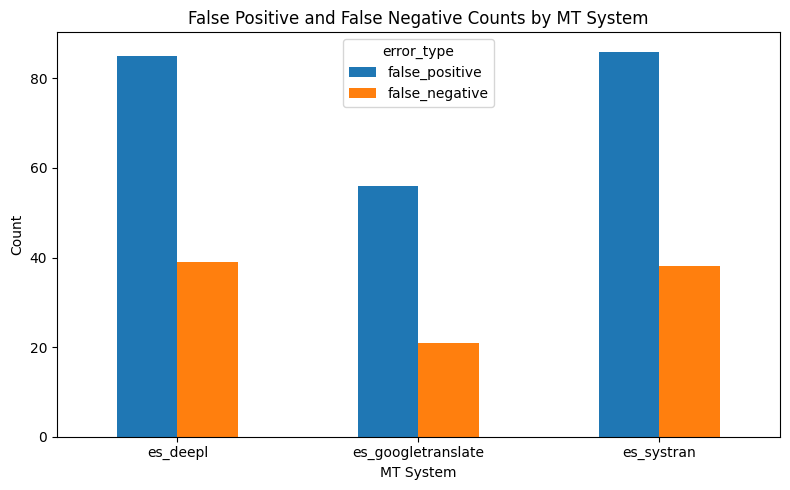

In [44]:
error_plot_df = (
    test_df.groupby(["system", "error_type"])
    .size()
    .unstack(fill_value=0)
)

for col in ["false_positive", "false_negative", "true_positive", "true_negative"]:
    if col not in error_plot_df.columns:
        error_plot_df[col] = 0

plot_cols = ["false_positive", "false_negative"]
error_plot_df = error_plot_df[plot_cols]

ax = error_plot_df.plot(kind="bar", figsize=(8, 5))
plt.title("False Positive and False Negative Counts by MT System")
plt.xlabel("MT System")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Correction Module
## first generate the correct spanish sentence

In [45]:
# build the replacem
def build_replacement_map(target_to_es):
    replacement_map = {}

    for target, lex in target_to_es.items():
        male_forms = sorted(list(lex["male"]))
        female_forms = sorted(list(lex["female"]))

        male_to_female = {}
        female_to_male = {}

        # pair by sorted order
        for m, f in zip(male_forms, female_forms):
            male_to_female[m.lower()] = f.lower()
            female_to_male[f.lower()] = m.lower()

        replacement_map[target] = {
            "male_to_female": male_to_female,
            "female_to_male": female_to_male
        }

    return replacement_map

# check
REPLACEMENT_MAP = build_replacement_map(TARGET_TO_ES)
print(REPLACEMENT_MAP["nurse"])

{'male_to_female': {'enfermero': 'enfermera', 'enfermeros': 'enfermeras'}, 'female_to_male': {'enfermera': 'enfermero', 'enfermeras': 'enfermeros'}}


In [46]:
def safe_phrase_replace(text, old_phrase, new_phrase):
    pattern = r"\b" + re.escape(old_phrase) + r"\b"
    return re.sub(pattern, new_phrase, text, flags=re.IGNORECASE)

In [47]:
def build_phrase_replacement_map(target_to_es):
    phrase_map = {}

    for target, lex in target_to_es.items():
        male_forms = {x.lower() for x in lex["male"]}
        female_forms = {x.lower() for x in lex["female"]}

        male_phrases = sorted([x for x in male_forms if " " in x], key=len, reverse=True)
        female_phrases = sorted([x for x in female_forms if " " in x], key=len, reverse=True)

        male_to_female = {}
        female_to_male = {}

        for m, f in zip(male_phrases, female_phrases):
            male_to_female[m] = f
            female_to_male[f] = m

        phrase_map[target] = {
            "male_to_female": male_to_female,
            "female_to_male": female_to_male
        }

    return phrase_map

PHRASE_REPLACEMENT_MAP = build_phrase_replacement_map(TARGET_TO_ES)
print(PHRASE_REPLACEMENT_MAP["ceo"])

{'male_to_female': {'director ejecutivo': 'directora ejecutiva'}, 'female_to_male': {'directora ejecutiva': 'director ejecutivo'}}


In [48]:
# safe replacement helpers
def safe_word_replace(text, old, new):
    pattern = r"\b" + re.escape(old) + r"\b"
    return re.sub(pattern, new, text, flags=re.IGNORECASE)

def correct_local_article(text, new_role, target_gender):
    """
    Conservative local article correction around the corrected profession form.
    Handles simple articles and common contractions like al/del.
    """
    if target_gender == "female":
        replacements = {
            r"\bal\s+" + re.escape(new_role) + r"\b": "a la " + new_role,
            r"\bdel\s+" + re.escape(new_role) + r"\b": "de la " + new_role,
            r"\bel\s+" + re.escape(new_role) + r"\b": "la " + new_role,
            r"\bun\s+" + re.escape(new_role) + r"\b": "una " + new_role,
            r"\blos\s+" + re.escape(new_role) + r"\b": "las " + new_role,
            r"\bunos\s+" + re.escape(new_role) + r"\b": "unas " + new_role,
        }
    else:
        replacements = {
            r"\ba la\s+" + re.escape(new_role) + r"\b": "al " + new_role,
            r"\bde la\s+" + re.escape(new_role) + r"\b": "del " + new_role,
            r"\bla\s+" + re.escape(new_role) + r"\b": "el " + new_role,
            r"\buna\s+" + re.escape(new_role) + r"\b": "un " + new_role,
            r"\blas\s+" + re.escape(new_role) + r"\b": "los " + new_role,
            r"\bunas\s+" + re.escape(new_role) + r"\b": "unos " + new_role,
        }

    out = text
    for pattern, replacement in replacements.items():
        out = re.sub(pattern, replacement, out, flags=re.IGNORECASE)

    # Optional: sentence-initial capitalization
    if len(out) > 0:
        out = out[0].upper() + out[1:]

    return out

# pseudo-correction
def generate_pseudo_correction(
    spanish_sentence,
    english_target,
    gold_gender,
    matched_role,
    detected_gender,
    replacement_map,
    phrase_replacement_map
):
    target = str(english_target).strip().lower()
    gold_gender = str(gold_gender).strip().lower()
    detected_gender = str(detected_gender).strip().lower()
    matched_role = str(matched_role).strip().lower()
    sentence = str(spanish_sentence)

    result = {
        "pseudo_corrected_text": spanish_sentence,
        "pseudo_correction_applied": False,
        "pseudo_correction_note": ""
    }

    if pd.isna(spanish_sentence) or str(spanish_sentence).strip() == "":
        result["pseudo_correction_note"] = "Empty translation"
        return result

    if target not in replacement_map:
        result["pseudo_correction_note"] = "Target not found in replacement map"
        return result

    if gold_gender not in {"male", "female"}:
        result["pseudo_correction_note"] = "Invalid gold gender"
        return result

    if detected_gender not in {"male", "female"}:
        result["pseudo_correction_note"] = "Detected gender not resolvable"
        return result

    if gold_gender == detected_gender:
        result["pseudo_correction_note"] = "Already consistent"
        return result

    # Decide direction
    if gold_gender == "female":
        replace_dict = replacement_map[target]["male_to_female"]
        phrase_dict = phrase_replacement_map.get(target, {}).get("male_to_female", {})
    else:
        replace_dict = replacement_map[target]["female_to_male"]
        phrase_dict = phrase_replacement_map.get(target, {}).get("female_to_male", {})

    # -------------------------
    # Pass 1: phrase replacement
    # -------------------------
    for old_phrase, new_phrase in sorted(phrase_dict.items(), key=lambda x: len(x[0]), reverse=True):
        if re.search(r"\b" + re.escape(old_phrase) + r"\b", sentence, flags=re.IGNORECASE):
            corrected_text = safe_phrase_replace(sentence, old_phrase, new_phrase)
            corrected_text = correct_local_article(corrected_text, new_phrase, gold_gender)

            result["pseudo_corrected_text"] = corrected_text
            result["pseudo_correction_applied"] = True
            result["pseudo_correction_note"] = f"Phrase-replaced '{old_phrase}' with '{new_phrase}'"
            return result

    # -------------------------
    # Pass 2: single-token replacement
    # -------------------------
    if matched_role == "":
        result["pseudo_correction_note"] = "No matched profession form"
        return result

    if matched_role not in replace_dict:
        result["pseudo_correction_note"] = "No opposite-gender form available in lexicon"
        return result

    corrected_role = replace_dict[matched_role]
    corrected_text = safe_word_replace(sentence, matched_role, corrected_role)
    corrected_text = correct_local_article(corrected_text, corrected_role, gold_gender)

    result["pseudo_corrected_text"] = corrected_text
    result["pseudo_correction_applied"] = True
    result["pseudo_correction_note"] = f"Replaced '{matched_role}' with '{corrected_role}'"

    return result

# apply pseudo-correction to one MT system
def apply_pseudo_correction_to_system(audit_df, system, replacement_map, phrase_replacement_map):
    sys_text_col = system
    matched_col = f"{system}_matched_role"
    detected_gender_col = f"{system}_detected_gender"
    status_col = f"{system}_status"

    rows = []

    for _, row in audit_df.iterrows():
        if row[status_col] != "GENDER MISMATCH":
            rows.append({
                f"{system}_pseudo_corrected_text": row[sys_text_col],
                f"{system}_pseudo_correction_applied": False,
                f"{system}_pseudo_correction_note": "Not a mismatch"
            })
            continue

        res = generate_pseudo_correction(
            spanish_sentence=row[sys_text_col],
            english_target=row["target"],
            gold_gender=row["gender"],
            matched_role=row[matched_col],
            detected_gender=row[detected_gender_col],
            replacement_map=replacement_map,
            phrase_replacement_map=phrase_replacement_map
        )

        rows.append({
            f"{system}_pseudo_corrected_text": res["pseudo_corrected_text"],
            f"{system}_pseudo_correction_applied": res["pseudo_correction_applied"],
            f"{system}_pseudo_correction_note": res["pseudo_correction_note"]
        })

    result_df = pd.DataFrame(rows)
    return pd.concat([audit_df.reset_index(drop=True), result_df], axis=1)

# apply to all 3 systems
def apply_pseudo_correction_all_systems(audit_df, replacement_map, phrase_replacement_map):
    output_df = audit_df.copy().reset_index(drop=True)

    for system in SYSTEMS:
        temp = apply_pseudo_correction_to_system(
            output_df,
            system,
            replacement_map,
            phrase_replacement_map
        )

        new_cols = [
            f"{system}_pseudo_corrected_text",
            f"{system}_pseudo_correction_applied",
            f"{system}_pseudo_correction_note"
        ]
        output_df[new_cols] = temp[new_cols]

    return output_df

In [49]:
REPLACEMENT_MAP = build_replacement_map(TARGET_TO_ES)
PHRASE_REPLACEMENT_MAP = build_phrase_replacement_map(TARGET_TO_ES)

pseudo_df = apply_pseudo_correction_all_systems(
    audit_df,
    REPLACEMENT_MAP,
    PHRASE_REPLACEMENT_MAP
)

'''
cols = [
    "target", "gender",
    "es_googletranslate", "es_googletranslate_status",
    "es_googletranslate_matched_role", "es_googletranslate_detected_gender",
    "es_googletranslate_pseudo_corrected_text",
    "es_googletranslate_pseudo_correction_applied",
    "es_googletranslate_pseudo_correction_note"
]

print(
    pseudo_df[cols]
    .sample(15, random_state=42)
    .to_string(index=False)
)
'''

check_cols = [
    "target", "gender",
    "es_googletranslate",
    "es_googletranslate_status",
    "es_googletranslate_matched_role",
    "es_googletranslate_detected_gender",
    "es_googletranslate_pseudo_corrected_text",
    "es_googletranslate_pseudo_correction_note"
]

ceo_cases = pseudo_df[pseudo_df["target"].str.lower() == "ceo"]
print(ceo_cases[check_cols].head(3).to_string(index=False))

target gender                                                            es_googletranslate es_googletranslate_status es_googletranslate_matched_role es_googletranslate_detected_gender                                       es_googletranslate_pseudo_corrected_text                       es_googletranslate_pseudo_correction_note
   CEO female              El director ejecutivo ayudó a la enfermera porque quería ayudar.           GENDER MISMATCH                        director                               male              La directora ejecutiva ayudó a la enfermera porque quería ayudar. Phrase-replaced 'director ejecutivo' with 'directora ejecutiva'
   CEO female El director general aumentó el sueldo de la recepcionista porque es generosa.           GENDER MISMATCH                        director                               male La directora general aumentó el sueldo de la recepcionista porque es generosa.                            Replaced 'director' with 'directora'
   CEO female   

### generate the correction spanish sentence

In [50]:
def build_correction_training_df(pseudo_df):
    rows = []

    for system in SYSTEMS:
        subset = pseudo_df[
            (pseudo_df[f"{system}_status"] == "GENDER MISMATCH") &
            (pseudo_df[f"{system}_pseudo_correction_applied"] == True)
        ].copy()

        for _, row in subset.iterrows():
            input_text = (
                "task=correct_gender_translation "
                + "target=" + str(row["target"]) + " "
                + "gender=" + str(row["gender"]) + " "
                + "label=" + str(row["label"]) + " "
                + "idx=" + str(row["idx"]) + " "
                + "system=" + str(system) + " "
                + "english=" + str(row["text"]) + " "
                + "spanish=" + str(row[system])
            )

            output_text = str(row[f"{system}_pseudo_corrected_text"])

            rows.append({
                "system": system,
                "target": row["target"],
                "gender": row["gender"],
                "label": row["label"],
                "idx": row["idx"],
                "english_text": row["text"],
                "original_spanish": row[system],
                "corrected_spanish": output_text,
                "model_input": input_text,
                "model_output": output_text
            })

    correction_df = pd.DataFrame(rows)
    return correction_df.reset_index(drop=True)

In [51]:
correction_df = build_correction_training_df(pseudo_df)

print(correction_df.shape)
print(correction_df.head(3).to_string(index=False))

(1798, 10)
            system    target gender label  idx                                                                english_text                                                           original_spanish                                                           corrected_spanish                                                                                                                                                                                                                                                                      model_input                                                                model_output
es_googletranslate developer female  anti    1 The developer argued with the designer because she did not like the design. El desarrollador discutió con el diseñador porque no le gustaba el diseño. La desarrolladora discutió con el diseñador porque no le gustaba el diseño. task=correct_gender_translation target=developer gender=female label=anti idx=1 system=es_go

In [52]:
print(correction_df["system"].value_counts().to_string())
print(correction_df["target"].value_counts().head(20).to_string())

system
es_systran            608
es_deepl              596
es_googletranslate    594
target
nurse                  113
tailor                 104
mechanic               101
carpenter              100
construction worker     93
driver                  93
farmer                  91
physician               89
chief                   86
baker                   71
laborer                 69
secretary               67
salesperson             66
supervisor              65
auditor                 63
editor                  60
developer               55
lawyer                  49
clerk                   47
CEO                     42


# Train correction model
## Using Hugging Face Dataset
### Load FLAN-T5-small

In [53]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    correction_df,
    test_size=0.2,
    random_state=42
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test:", test_df.shape)

Train: (1438, 10)
Valid: (180, 10)
Test: (180, 10)


In [54]:
train_df.to_csv("correction_train.csv", index=False)
valid_df.to_csv("correction_valid.csv", index=False)
test_df.to_csv("correction_test.csv", index=False)

In [55]:
!pip install -q transformers datasets sentencepiece accelerate evaluate sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.6 MB/s eta 0:00:00


In [56]:
from datasets import Dataset, DatasetDict

dataset_dict = DatasetDict({
    "train": Dataset.from_pandas(train_df[["model_input", "model_output"]].reset_index(drop=True)),
    "validation": Dataset.from_pandas(valid_df[["model_input", "model_output"]].reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df[["model_input", "model_output"]].reset_index(drop=True)),
})

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['model_input', 'model_output'],
        num_rows: 1438
    })
    validation: Dataset({
        features: ['model_input', 'model_output'],
        num_rows: 180
    })
    test: Dataset({
        features: ['model_input', 'model_output'],
        num_rows: 180
    })
})

In [57]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [58]:
max_input_length = 256
max_target_length = 128

def preprocess_function(examples):
    model_inputs = tokenizer(
        examples["model_input"],
        max_length=max_input_length,
        truncation=True,
        padding=False,
    )

    labels = tokenizer(
        text_target=examples["model_output"],
        max_length=max_target_length,
        truncation=True,
        padding=False,
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_datasets = dataset_dict.map(
    preprocess_function,
    batched=True,
    remove_columns=dataset_dict["train"].column_names
)

Map:   0%|          | 0/1438 [00:00<?, ? examples/s]

Map:   0%|          | 0/180 [00:00<?, ? examples/s]

Map:   0%|          | 0/180 [00:00<?, ? examples/s]

In [59]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

In [60]:
import evaluate

rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [label.strip() for label in decoded_labels]

    exact_match = np.mean([
        int(pred == label)
        for pred, label in zip(decoded_preds, decoded_labels)
    ])

    rouge_result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=False
    )

    return {
        "exact_match": exact_match,
        "rouge1": rouge_result["rouge1"],
        "rougeL": rouge_result["rougeL"],
    }

In [61]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

training_args = Seq2SeqTrainingArguments(
    output_dir="./flan_t5_correction_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=3e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=5,
    predict_with_generate=True,
    fp16=False,
    load_best_model_at_end=True,
    metric_for_best_model="exact_match",
    greater_is_better=True,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [62]:
trainer.train()

Epoch,Training Loss,Validation Loss,Exact Match,Rouge1,Rougel
1,0.059663,0.031912,0.000000,0.680823,0.671870
2,0.039579,0.026792,0.000000,0.687225,0.674530
3,0.034085,0.016191,0.000000,0.707354,0.698324
4,0.017497,0.008168,0.000000,0.733955,0.733359
5,0.012963,0.007163,0.000000,0.736589,0.736969


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


TrainOutput(global_step=900, training_loss=0.040857708321677316, metrics={'train_runtime': 125.4051, 'train_samples_per_second': 57.334, 'train_steps_per_second': 7.177, 'total_flos': 274175424012288.0, 'train_loss': 0.040857708321677316, 'epoch': 5.0})

In [63]:
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
print("Validation metrics:", val_metrics)

test_metrics = trainer.evaluate(tokenized_datasets["test"])
print("Test metrics:", test_metrics)

Validation metrics: {'eval_loss': 0.03191197291016579, 'eval_exact_match': 0.0, 'eval_rouge1': 0.6808233390700159, 'eval_rougeL': 0.6718700432165379, 'eval_runtime': 7.5895, 'eval_samples_per_second': 23.717, 'eval_steps_per_second': 3.03, 'epoch': 5.0}
Test metrics: {'eval_loss': 0.036462318152189255, 'eval_exact_match': 0.005555555555555556, 'eval_rouge1': 0.6703938560456617, 'eval_rougeL': 0.6586173746739756, 'eval_runtime': 7.577, 'eval_samples_per_second': 23.756, 'eval_steps_per_second': 3.036, 'epoch': 5.0}


In [64]:
import torch

def generate_prediction(text, max_new_tokens=64):
    model.eval()
    device = model.device

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_input_length
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

sample_test = test_df.sample(3, random_state=42).copy()

for _, row in sample_test.iterrows():
    pred = generate_prediction(row["model_input"])
    print("=" * 80)
    print("INPUT:")
    print(row["model_input"])
    print("\nGOLD OUTPUT:")
    print(row["model_output"])
    print("\nPREDICTED OUTPUT:")
    print(pred)
    print()

INPUT:
task=correct_gender_translation target=secretary gender=male label=anti idx=4 system=es_deepl english=The physician called the secretary and asked him to cancel an appointment. spanish=La doctora llamó a la secretaria y le pidió que cancelara una cita.

GOLD OUTPUT:
La doctora llamó al secretario y le pidió que cancelara una cita.

PREDICTED OUTPUT:
La doctora llamó al secretario y le pidió que cancelara una cita.

INPUT:
task=correct_gender_translation target=mechanic gender=female label=anti idx=1 system=es_systran english=The mechanic talked with the counselor for such a long time because she knew little about the legal affairs. spanish=El mecánico habló con el consejero durante tanto tiempo porque sabía poco sobre los asuntos legales.

GOLD OUTPUT:
La mecánica habló con el consejero durante tanto tiempo porque sabía poco sobre los asuntos legales.

PREDICTED OUTPUT:
El mecánico habló con la consejera durante tanto tiempo porque saba poco sobre los asuntos legales.

INPUT:
ta

## TF-IDF + Logistic Regression / Linear SVM

In [65]:
def extract_corrected_role_from_note(note):
    if pd.isna(note):
        return ""
    note = str(note)
    m = re.search(r"with '([^']+)'", note)
    if m:
        return m.group(1).strip().lower()
    return ""

def build_form_correction_df(pseudo_df):
    rows = []

    for system in SYSTEMS:
        subset = pseudo_df[
            (pseudo_df[f"{system}_status"] == "GENDER MISMATCH") &
            (pseudo_df[f"{system}_pseudo_correction_applied"] == True)
        ].copy()

        for _, row in subset.iterrows():
            matched_role = str(row[f"{system}_matched_role"]).strip().lower()
            correction_note = row[f"{system}_pseudo_correction_note"]
            corrected_role = extract_corrected_role_from_note(correction_note)

            if matched_role == "" or corrected_role == "":
                continue

            input_text = (
                "task=predict_corrected_profession "
                + "target=" + str(row["target"]) + " "
                + "gender=" + str(row["gender"]) + " "
                + "label=" + str(row["label"]) + " "
                + "idx=" + str(row["idx"]) + " "
                + "system=" + str(system) + " "
                + "matched_role=" + matched_role + " "
                + "english=" + str(row["text"]) + " "
                + "spanish=" + str(row[system])
            )

            rows.append({
                "system": system,
                "target": row["target"],
                "gender": row["gender"],
                "label": row["label"],
                "idx": row["idx"],
                "english_text": row["text"],
                "original_spanish": row[system],
                "matched_role": matched_role,
                "corrected_role": corrected_role,
                "model_input": input_text,
            })

    return pd.DataFrame(rows).reset_index(drop=True)

In [66]:
form_df = build_form_correction_df(pseudo_df)
print(form_df.shape)
print(form_df.head(5).to_string(index=False))
print(form_df["corrected_role"].value_counts().head(5).to_string())

(1798, 10)
            system      target gender label  idx                                                                english_text                                                            original_spanish  matched_role corrected_role                                                                                                                                                                                                                                                                                                   model_input
es_googletranslate   developer female  anti    1 The developer argued with the designer because she did not like the design.  El desarrollador discutió con el diseñador porque no le gustaba el diseño. desarrollador desarrolladora task=predict_corrected_profession target=developer gender=female label=anti idx=1 system=es_googletranslate matched_role=desarrollador english=The developer argued with the designer because she did not like the design. spanish=

In [67]:
from sklearn.model_selection import train_test_split

role_counts = form_df["corrected_role"].value_counts()
valid_roles = role_counts[role_counts >= 3].index
form_df_filtered = form_df[form_df["corrected_role"].isin(valid_roles)].copy()

train_form_df, temp_form_df = train_test_split(
    form_df_filtered,
    test_size=0.2,
    random_state=42,
    stratify=form_df_filtered["corrected_role"]
)

valid_form_df, test_form_df = train_test_split(
    temp_form_df,
    test_size=0.5,
    random_state=42
)

print("Train:", train_form_df.shape)
print("Valid:", valid_form_df.shape)
print("Test :", test_form_df.shape)

Train: (1432, 10)
Valid: (179, 10)
Test : (179, 10)


In [68]:
groups = form_df["english_text"]

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(gss1.split(form_df, groups=groups))

train_form_df = form_df.iloc[train_idx].reset_index(drop=True)
temp_form_df = form_df.iloc[temp_idx].reset_index(drop=True)

temp_groups = temp_form_df["english_text"]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
valid_idx, test_idx = next(gss2.split(temp_form_df, groups=temp_groups))

valid_form_df = temp_form_df.iloc[valid_idx].reset_index(drop=True)
test_form_df = temp_form_df.iloc[test_idx].reset_index(drop=True)

X_train = train_form_df["model_input"]
y_train = train_form_df["corrected_role"]

X_valid = valid_form_df["model_input"]
y_valid = valid_form_df["corrected_role"]

X_test = test_form_df["model_input"]
y_test = test_form_df["corrected_role"]

logreg_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("clf", LinearSVC(
        class_weight="balanced"
    ))
])


In [69]:
def evaluate_role_model(model, X, y, split_name="Validation"):
    pred = model.predict(X)

    print(f"\n===== {split_name} =====")
    print("Accuracy:", round(accuracy_score(y, pred), 4))
    print("Macro F1:", round(f1_score(y, pred, average="macro"), 4))
    print("\nClassification Report:")
    print(classification_report(y, pred, digits=4))

    return pred

In [70]:
# Logistic Regression
logreg_pipeline.fit(X_train, y_train)
valid_pred_logreg = evaluate_role_model(logreg_pipeline, X_valid, y_valid, "Validation - Logistic Regression")

# Linear SVM
svm_pipeline.fit(X_train, y_train)
valid_pred_svm = evaluate_role_model(svm_pipeline, X_valid, y_valid, "Validation - Linear SVM")


===== Validation - Logistic Regression =====
Accuracy: 0.9819
Macro F1: 0.9428

Classification Report:
                precision    recall  f1-score   support

       abogada     1.0000    1.0000    1.0000         2
   agricultora     1.0000    1.0000    1.0000         2
       auditor     1.0000    1.0000    1.0000         1
      auditora     1.0000    1.0000    1.0000         6
 bibliotecaria     1.0000    1.0000    1.0000         1
 bibliotecario     1.0000    1.0000    1.0000         1
        cajera     1.0000    1.0000    1.0000         1
        cajero     1.0000    1.0000    1.0000         1
    carpintera     1.0000    1.0000    1.0000        10
      cocinera     1.0000    1.0000    1.0000         2
    conductora     1.0000    1.0000    1.0000         7
     consejera     1.0000    1.0000    1.0000         5
     contadora     1.0000    1.0000    1.0000         3
desarrolladora     1.0000    1.0000    1.0000         2
     directora     1.0000    1.0000    1.0000         1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_


===== Validation - Linear SVM =====
Accuracy: 0.994
Macro F1: 0.9897

Classification Report:
                precision    recall  f1-score   support

       abogada     1.0000    1.0000    1.0000         2
   agricultora     1.0000    1.0000    1.0000         2
       auditor     1.0000    1.0000    1.0000         1
      auditora     1.0000    1.0000    1.0000         6
 bibliotecaria     1.0000    1.0000    1.0000         1
 bibliotecario     1.0000    1.0000    1.0000         1
        cajera     1.0000    1.0000    1.0000         1
        cajero     1.0000    1.0000    1.0000         1
    carpintera     1.0000    1.0000    1.0000        10
      cocinera     1.0000    1.0000    1.0000         2
    conductora     1.0000    1.0000    1.0000         7
     consejera     1.0000    1.0000    1.0000         5
     contadora     1.0000    1.0000    1.0000         3
desarrolladora     1.0000    1.0000    1.0000         2
     directora     1.0000    1.0000    1.0000         1
    diseñ

In [71]:
best_model = logreg_pipeline  # 或 logreg_pipeline svm_pipeline

test_pred = evaluate_role_model(best_model, X_test, y_test, "Test - Best Model")


===== Test - Best Model =====
Accuracy: 0.9831
Macro F1: 0.89

Classification Report:
                     precision    recall  f1-score   support

            abogada     1.0000    1.0000    1.0000         7
        agricultora     1.0000    1.0000    1.0000         1
          asistenta     0.0000    0.0000    0.0000         1
           auditora     1.0000    1.0000    1.0000         4
      bibliotecaria     1.0000    1.0000    1.0000         1
      bibliotecario     1.0000    1.0000    1.0000         1
             cajera     1.0000    1.0000    1.0000         3
             cajero     1.0000    1.0000    1.0000         2
         carpintera     1.0000    1.0000    1.0000         7
           cocinera     1.0000    1.0000    1.0000         1
         conductora     1.0000    1.0000    1.0000         9
          consejera     0.6667    1.0000    0.8000         2
          consejero     0.0000    0.0000    0.0000         1
          contadora     1.0000    1.0000    1.0000        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [72]:
best_model = svm_pipeline  # 或 logreg_pipeline svm_pipeline

test_pred = evaluate_role_model(best_model, X_test, y_test, "Test - Best Model")


===== Test - Best Model =====
Accuracy: 0.9831
Macro F1: 0.8886

Classification Report:
                     precision    recall  f1-score   support

            abogada     1.0000    1.0000    1.0000         7
        agricultora     1.0000    1.0000    1.0000         1
          asistenta     0.0000    0.0000    0.0000         1
           auditora     1.0000    1.0000    1.0000         4
      bibliotecaria     1.0000    1.0000    1.0000         1
      bibliotecario     1.0000    1.0000    1.0000         1
             cajera     1.0000    1.0000    1.0000         3
             cajero     1.0000    1.0000    1.0000         2
         carpintera     1.0000    1.0000    1.0000         7
           cocinera     1.0000    1.0000    1.0000         1
         conductora     1.0000    1.0000    1.0000         9
          consejera     0.6667    1.0000    0.8000         2
          consejero     0.0000    0.0000    0.0000         1
          contadora     1.0000    1.0000    1.0000      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [73]:
test_pred_df = test_form_df.copy()
test_pred_df["predicted_role"] = test_pred

In [74]:
def safe_word_replace(text, old, new):
    pattern = r"\b" + re.escape(old) + r"\b"
    return re.sub(pattern, new, text, flags=re.IGNORECASE)

def correct_local_article(text, new_role, target_gender):
    if target_gender == "female":
        replacements = {
            r"\bal\s+" + re.escape(new_role) + r"\b": "a la " + new_role,
            r"\bdel\s+" + re.escape(new_role) + r"\b": "de la " + new_role,
            r"\bel\s+" + re.escape(new_role) + r"\b": "la " + new_role,
            r"\bun\s+" + re.escape(new_role) + r"\b": "una " + new_role,
            r"\blos\s+" + re.escape(new_role) + r"\b": "las " + new_role,
            r"\bunos\s+" + re.escape(new_role) + r"\b": "unas " + new_role,
        }
    else:
        replacements = {
            r"\ba la\s+" + re.escape(new_role) + r"\b": "al " + new_role,
            r"\bde la\s+" + re.escape(new_role) + r"\b": "del " + new_role,
            r"\bla\s+" + re.escape(new_role) + r"\b": "el " + new_role,
            r"\buna\s+" + re.escape(new_role) + r"\b": "un " + new_role,
            r"\blas\s+" + re.escape(new_role) + r"\b": "los " + new_role,
            r"\bunas\s+" + re.escape(new_role) + r"\b": "unos " + new_role,
        }

    out = text
    for pattern, replacement in replacements.items():
        out = re.sub(pattern, replacement, out, flags=re.IGNORECASE)

    if len(out) > 0:
        out = out[0].upper() + out[1:]

    return out

def write_predicted_role_back(spanish_sentence, matched_role, predicted_role, gold_gender):
    matched_role = str(matched_role).strip().lower()
    predicted_role = str(predicted_role).strip().lower()

    if matched_role == "" or predicted_role == "":
        return spanish_sentence

    corrected_text = safe_word_replace(str(spanish_sentence), matched_role, predicted_role)
    corrected_text = correct_local_article(corrected_text, predicted_role, str(gold_gender).strip().lower())
    return corrected_text

In [75]:
test_pred_df["predicted_corrected_spanish"] = test_pred_df.apply(
    lambda row: write_predicted_role_back(
        spanish_sentence=row["original_spanish"],
        matched_role=row["matched_role"],
        predicted_role=row["predicted_role"],
        gold_gender=row["gender"]
    ),
    axis=1
)

print(
    test_pred_df[
        ["target", "gender", "original_spanish", "matched_role", "corrected_role", "predicted_role", "predicted_corrected_spanish"]
    ]
    .head(5)
    .to_string(index=False)
)

   target gender                                                                                                     original_spanish matched_role corrected_role predicted_role                                                                                          predicted_corrected_spanish
physician female                                                El médico le dijo al panadero que ella había hecho lo mejor que pudo.       médico         médica         médica                                                La médica le dijo al panadero que ella había hecho lo mejor que pudo.
   lawyer female                  El abogado investigó las acusaciones ilegales contra el cajero, porque necesitaba entender el caso.      abogado        abogada        abogada                  La abogada investigó las acusaciones ilegales contra el cajero, porque necesitaba entender el caso.
secretary   male                                                   El desarrollador corrigió a la secretaria porque co

In [76]:
role_exact_match = (
    test_pred_df["predicted_role"].str.lower() ==
    test_pred_df["corrected_role"].str.lower()
).mean()

print("Role exact match:", round(role_exact_match, 4))

Role exact match: 0.9831


In [77]:
# count the mismatch before
reaudit_rows = []

for _, row in test_pred_df.iterrows():
    audit_result = audit_translation_row(
        spanish_sentence=row["predicted_corrected_spanish"],
        target=row["target"],
        gold_gender=row["gender"],
        target_to_es=TARGET_TO_ES
    )
    reaudit_rows.append(audit_result)

reaudit_df = pd.DataFrame(reaudit_rows)

test_pred_df = pd.concat(
    [test_pred_df.reset_index(drop=True), reaudit_df.reset_index(drop=True)],
    axis=1
)

print(test_pred_df["Audit_Status"].value_counts().to_string())

Audit_Status
CONSISTENT         175
GENDER MISMATCH      2


In [78]:
# count the mismatch after train
before_mismatch = len(test_pred_df)
after_counts = test_pred_df["Audit_Status"].value_counts()

after_mismatch = after_counts.get("GENDER MISMATCH", 0)
after_consistent = after_counts.get("CONSISTENT", 0)
after_unresolved = after_counts.get("UNRESOLVED", 0)

print("Before correction mismatch count:", before_mismatch)
print("After correction mismatch count :", after_mismatch)
print("After correction consistent count:", after_consistent)
print("After correction unresolved count:", after_unresolved)

print("Mismatch reduction rate:", round((before_mismatch - after_mismatch) / before_mismatch, 4))

Before correction mismatch count: 177
After correction mismatch count : 2
After correction consistent count: 175
After correction unresolved count: 0
Mismatch reduction rate: 0.9887


In [79]:
failed_cases = test_pred_df[test_pred_df["Audit_Status"] != "CONSISTENT"].copy()

print(
    failed_cases[
        [
            "target", "gender",
            "original_spanish",
            "matched_role",
            "corrected_role",
            "predicted_role",
            "predicted_corrected_spanish",
            "Audit_Status",
            "Note"
        ]
    ]
    .head(30)
    .to_string(index=False)
)

   target gender                                                             original_spanish matched_role corrected_role predicted_role                                                  predicted_corrected_spanish    Audit_Status Note
counselor   male         El conserje limpió la oficina de la consejera porque él se lo pidió.    consejera      consejero      consejera           El conserje limpió la oficina del consejera porque él se lo pidió. GENDER MISMATCH     
   writer   male El abogado fue contratado por la escritora y luego recibió asistencia legal.    escritora       escritor      escritora El abogado fue contratado por el escritora y luego recibió asistencia legal. GENDER MISMATCH     


### FLAN-T5-small vs. mT5-small

In [80]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/mt5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [81]:
from datasets import Dataset, DatasetDict

mt5_dataset = DatasetDict({
    "train": Dataset.from_pandas(
        train_form_df[["model_input", "corrected_role"]]
        .rename(columns={"corrected_role": "model_output"})
        .reset_index(drop=True)
    ),
    "validation": Dataset.from_pandas(
        valid_form_df[["model_input", "corrected_role"]]
        .rename(columns={"corrected_role": "model_output"})
        .reset_index(drop=True)
    ),
    "test": Dataset.from_pandas(
        test_form_df[["model_input", "corrected_role"]]
        .rename(columns={"corrected_role": "model_output"})
        .reset_index(drop=True)
    ),
})

In [82]:
max_input_length = 256
max_target_length = 16

def preprocess_mt5_function(examples):
    model_inputs = tokenizer(
        examples["model_input"],
        max_length=max_input_length,
        truncation=True,
        padding=False,
    )

    labels = tokenizer(
        text_target=examples["model_output"],
        max_length=max_target_length,
        truncation=True,
        padding=False,
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_mt5_dataset = mt5_dataset.map(
    preprocess_mt5_function,
    batched=True,
    remove_columns=mt5_dataset["train"].column_names
)

Map:   0%|          | 0/1455 [00:00<?, ? examples/s]

Map:   0%|          | 0/166 [00:00<?, ? examples/s]

Map:   0%|          | 0/177 [00:00<?, ? examples/s]

In [83]:
def normalize_role_text(s):
    s = str(s).strip().lower()
    s = re.sub(r"\s+", " ", s)
    return s

def compute_mt5_form_metrics(eval_pred):
    predictions, labels = eval_pred

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [normalize_role_text(x) for x in decoded_preds]
    decoded_labels = [normalize_role_text(x) for x in decoded_labels]

    exact_match = np.mean([
        int(pred == label)
        for pred, label in zip(decoded_preds, decoded_labels)
    ])

    return {
        "exact_match": exact_match
    }

In [84]:
from transformers import DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

training_args = Seq2SeqTrainingArguments(
    output_dir="./mt5_form_correction_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=3e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=5,
    predict_with_generate=True,
    fp16=False,
    load_best_model_at_end=True,
    metric_for_best_model="exact_match",
    greater_is_better=True,
    report_to="none"
)

mt5_trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_mt5_dataset["train"],
    eval_dataset=tokenized_mt5_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_mt5_form_metrics,
)

In [85]:
mt5_trainer.train()

Epoch,Training Loss,Validation Loss,Exact Match
1,3.884225,0.542674,0.590361
2,0.561100,0.162907,0.927711
3,0.262099,0.118353,0.933735
4,0.139931,0.108911,0.933735
5,0.086507,0.090985,0.945783


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=910, training_loss=2.112520237545391, metrics={'train_runtime': 176.5139, 'train_samples_per_second': 41.215, 'train_steps_per_second': 5.155, 'total_flos': 683024805765120.0, 'train_loss': 2.112520237545391, 'epoch': 5.0})

In [86]:
print("Validation:", mt5_trainer.evaluate(tokenized_mt5_dataset["validation"]))
print("Test:", mt5_trainer.evaluate(tokenized_mt5_dataset["test"]))

Validation: {'eval_loss': 0.09098492562770844, 'eval_exact_match': 0.9457831325301205, 'eval_runtime': 2.2569, 'eval_samples_per_second': 73.552, 'eval_steps_per_second': 9.305, 'epoch': 5.0}
Test: {'eval_loss': 0.2351134717464447, 'eval_exact_match': 0.943502824858757, 'eval_runtime': 2.5247, 'eval_samples_per_second': 70.108, 'eval_steps_per_second': 9.11, 'epoch': 5.0}


In [87]:
print("Validation:", mt5_trainer.evaluate(tokenized_mt5_dataset["validation"]))
print("Test:", mt5_trainer.evaluate(tokenized_mt5_dataset["test"]))

Validation: {'eval_loss': 0.09098492562770844, 'eval_exact_match': 0.9457831325301205, 'eval_runtime': 2.1698, 'eval_samples_per_second': 76.505, 'eval_steps_per_second': 9.678, 'epoch': 5.0}
Test: {'eval_loss': 0.2351134717464447, 'eval_exact_match': 0.943502824858757, 'eval_runtime': 2.3667, 'eval_samples_per_second': 74.789, 'eval_steps_per_second': 9.718, 'epoch': 5.0}


In [88]:
import torch

def predict_corrected_role_mt5(text, max_new_tokens=8):
    model.eval()
    device = model.device

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_input_length
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True).strip().lower()